# Latin BERT on LatinISE for Christian-related semantic change

WARNINGS: 

(1) This code may take a few hours to run. As repeated where relevant below, `rebuild` needs to be set to `True` to output files containing embeddings for the first time. Results can be loaded from the pickle files for subsequent runs, with `rebuild` set to `False`.

(2) Latin BERT (Bamman and Burns, 2020) needs to be installed: https://github.com/dbamman/latin-bert/tree/master.needs 

(3) TODO [Our finetuned version of Latin BERT needs to be downloaded. See instructions on the README file.]

The structure of this notebook is as follows:
- Import packages and define functions
- Set up metadata dataframes
    - Redefine the timeframe of interest (LatinISE covers a wide timespan, but we are only interested in Latin while a living language)
    - Define time slices (so that the first precedes Christian Latin texts and the second one contains them)
    - Define Christian and non-Christian subcorpora within second timeframe
- Build corpus and subcorpora
- Pre-trained Latin BERT
    - Extract embeddings for each subcorpus
    - Average embeddings per word type and calculate cosine similarity across subcorpora
    - Try different techniques for clustering embeddings as to maintain sense distinction
    - Plot some results via PCA
- Fine-tuned Latin BERT
    - Repeat embedding extraction, averaging, clustering, and plotting

One more warning: the kernel might die if you try and run both the 'pre-trained' and 'fine-tuned' sections of the notebook. If this happens, try and deal with either one at one time, but not both.

## Packages and functions

Import packages:

In [2]:
import os 
import csv
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gen_berts import LatinBERT
from collections import defaultdict, Counter
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import silhouette_score
import torch
from transformers import AutoModel, AutoTokenizer

Define frequently used functions:

(1) `calculate_or_load_embeddings` either extracts embeddings for the pre-trained model the first time and saves them to a pickle file (if `rebuild = True`) or loads them from the previously saved pickle file (if `rebuild = False`).

(2) `calculate_or_load__finetuned_embeddings` either extracts embeddings for the fine tuned model for the first time and saves them to a pickle file (if `rebuild = True`) or loads them from the previously saved pickle file (if `rebuild = False`).

(3) `average_embeddings_per_lemma` computes an average embedding for each word type (we use a lemmatised corpus here) and saves them to a pickle file (if `rebuild = True`) or loads them from the previously saved pickle file (if `rebuild = False`); also prints the averaged embeddings for the 10 most frequent words as sample. 

(4) `find_neighbors` shows which averaged embeddings are most similar to the target embedding, and displays the cosine similarity score for each of them.

(5) `cluster_embeddings` clusters embeddings for each word type (we use a lemmatised corpus here) and saves them to a pickle file (if `rebuild = True`) or loads them from the previously saved pickle file (if `rebuild = False`); also prints the clustered embeddings for the first 10 most frequent words as sample.

(6) `cluster_target_embeddings` does the same, but does not rely on `rebuild` or previously defined files.

(7) `extract_selected_embeddings` extracts embeddings only for a given set of words.

In [3]:
def calculate_or_load_embeddings(corpus, dir_out, output_filename, rebuild, tokenizer_path, bert_path, max_seq_length=512):
    output_file = os.path.join(dir_out, output_filename)
    
    if rebuild == True:
        # Initialize the LatinBERT class
        latin_bert = LatinBERT(tokenizerPath=tokenizer_path, bertPath=bert_path)
        
        # Flatten the lists into strings and truncate to max_seq_length
        flattened_corpus = [' '.join(sent)[:max_seq_length] for sent in corpus]
        
        # Process the corpus using the get_berts method
        bert_sents = latin_bert.get_berts(flattened_corpus)
        
        # Save the results to a pickle file
        with open(output_file, 'wb') as f:
            pickle.dump(bert_sents, f)
        print(f"Results saved to {output_file}")
    elif rebuild == False:
        # Load the results from the pickle file
        with open(output_file, 'rb') as f:
            bert_sents = pickle.load(f)
    
    return bert_sents

In [53]:
def calculate_or_load_finetuned_embeddings(corpus, model_name, output_path, rebuild, batch_size=32):
    """
    Calculate embeddings for a given corpus using a Hugging Face-compatible tokenizer and model.

    Args:
        corpus (list of list of str): List of tokenized sentences (each sentence is a list of words).
        model_name (str): Name or path of the Hugging Face model to use.
        output_path (str): Path to save the calculated embeddings.
        rebuild (bool): Whether to calculate embeddings (True) or load from file (False).
        batch_size (int): Batch size for processing sentences.

    Returns:
        list: A list of sentence embeddings, where each sentence is a list of (word, embedding) tuples.
    """

    # Check if embeddings already exist
    if rebuild == False and os.path.exists(output_path):
        print(f"Loading embeddings from {output_path}...")
        with open(output_path, "rb") as f:
            return pickle.load(f)
        
    elif rebuild == True:

        # Load tokenizer and model
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name)
        model.eval()  # Set model to evaluation mode

        # Device setup (GPU if available)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)

        # Initialize list to store embeddings for all sentences
        all_embeddings = []

        # Process sentences in batches
        for i in range(0, len(corpus), batch_size):
            batch = corpus[i:i + batch_size]

            # Tokenize with word alignment
            inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True,
                            is_split_into_words=True, max_length=512)
            inputs = {key: val.to(device) for key, val in inputs.items()}

            # Forward pass to get embeddings
            with torch.no_grad():
                outputs = model(**inputs)

            # Extract embeddings (use the last hidden state)
            last_hidden_state = outputs.last_hidden_state

            # For each sentence in the batch
            for j, sentence in enumerate(batch):
                word_ids = tokenizer(batch[j], is_split_into_words=True).word_ids()
                sentence_embedding = []

                # Add [CLS] token embedding
                cls_embedding = last_hidden_state[j, 0].cpu().numpy()
                sentence_embedding.append(("[CLS]", cls_embedding))

                # Add word embeddings
                for word_idx in sorted(set(wid for wid in word_ids if wid is not None)):
                    if word_idx is None:
                        continue
                    
                    # Get the token indices corresponding to the word
                    token_indices = [idx for idx, wid in enumerate(word_ids) if wid == word_idx]

                    # Filter out indices that are out of bounds
                    token_indices = [idx for idx in token_indices if idx < last_hidden_state.size(1)]

                    # Skip if token_indices is empty
                    if not token_indices:
                        print(f"Skipping word_idx {word_idx} due to empty or invalid token_indices.")
                        continue

                    # Average the embeddings for the tokens corresponding to the word
                    word_embedding = last_hidden_state[j, token_indices, :].mean(dim=0).cpu().numpy()

                    # Get the word (lemma) from the original sentence
                    lemma = sentence[word_idx]

                    # Append the lemma and its embedding
                    sentence_embedding.append((lemma, word_embedding))

                # Add [SEP] token embedding
                sep_embedding = last_hidden_state[j, -1].cpu().numpy()
                sentence_embedding.append(("[SEP]", sep_embedding))

                # Append full sentence embedding to master list
                all_embeddings.append(sentence_embedding)

        # Save to file
        with open(output_path, "wb") as f:
            pickle.dump(all_embeddings, f)

        print(f"Embeddings saved to {output_path}.")
        return all_embeddings

In [4]:
def average_embeddings_per_lemma(bert_sents, dir_out, output_filename, rebuild, num_most_frequent=10):
    """
    Process embeddings for each word type, compute average embeddings, and print the most frequent words.

    Parameters:
    - bert_sents: List of sentences with BERT embeddings [(word, embedding), ...]
    - dir_out: Output directory to save the average embeddings
    - output_filename: Name of the output file to save the average embeddings
    - rebuild: Boolean flag to indicate whether to rebuild the embeddings or load from file
    - num_most_frequent: Number of most frequent words to display

    Returns:
    - average_embeddings: Dictionary of average embeddings for each word type
    - most_frequent_words: List of the most frequent words
    """
    # Ensure the output directory exists
    os.makedirs(dir_out, exist_ok=True)
    
    average_embeddings_file = os.path.join(dir_out, output_filename)

    # Dictionary to store embeddings for each word type
    word_embeddings = defaultdict(list)
    
    # Collect all embeddings for each word type and count word frequencies
    word_counter = Counter()
    for sent in bert_sents:
        for lemma, embedding in sent:
            word_embeddings[lemma].append(embedding)
            word_counter[lemma] += 1

    if rebuild == True:
        # Compute the average embedding for each word type
        average_embeddings = {}
        for word, embeddings in word_embeddings.items():
            embeddings_array = np.array(embeddings)
            average_embeddings[word] = np.mean(embeddings_array, axis=0)

        # Save the average embeddings to a pickle file
        with open(average_embeddings_file, 'wb') as f:
            pickle.dump(average_embeddings, f)

        print(f"Average embeddings saved to {average_embeddings_file}")

    elif rebuild == False:
        # Load the average embeddings from the pickle file
        with open(average_embeddings_file, 'rb') as f:
            average_embeddings = pickle.load(f)
        
    # Get the most frequent words
    most_frequent_words = [word for word, _ in word_counter.most_common(num_most_frequent)]

    # Print the embeddings for the most frequent words
    for word in most_frequent_words:
        embedding = average_embeddings[word]
        print(f"Word: {word}")
        print(f"Embedding: {embedding}\n")

    return average_embeddings, most_frequent_words

In [5]:
def find_neighbors(target_word, average_embeddings, top_k=5):
    """
    Find the top-k nearest neighbors for the target word using precomputed average embeddings.

    Parameters:
    - target_word: The word for which to find neighbors.
    - average_embeddings: Dictionary of precomputed average embeddings for each word.
    - top_k: Number of nearest neighbors to find.

    Returns:
    - neighbors: List of nearest neighbors for the target word.
    """
    if target_word not in average_embeddings:
        raise ValueError(f"Word '{target_word}' not found in the corpus.")

    target_embedding = average_embeddings[target_word].reshape(1, -1)
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[word] for word in all_words])

    # Compute cosine similarities
    similarities = cosine_similarity(target_embedding, all_embeddings).squeeze()

    # Exclude target word and find the top-k neighbors
    neighbors = sorted(
        [(word, sim) for word, sim in zip(all_words, similarities) if word != target_word],
        key=lambda x: -x[1]
    )[:top_k]

    return neighbors

In [6]:
def cluster_embeddings(bert_sents, dir_out, output_filename, rebuild, num_clusters=3):
    """
    Clusters embeddings for each word type and saves or loads the clustered embeddings.

    Args:
        bert_sents (list): List of sentences with tokens and their embeddings.
        dir_out (str): Directory to save or load the clustered embeddings.
        output_filename (str): Name of the pickle file to save/load clustered embeddings.
        rebuild (bool): Whether to rebuild the clusters or load from file.
        num_clusters (int): Number of clusters for each word type.

    Returns:
        dict: A dictionary with words as keys and their clustered embeddings as values.
    """
    clustered_embeddings_file = os.path.join(dir_out, output_filename)

    # Dictionary to store embeddings for each word type
    word_embeddings = defaultdict(list)

    # Collect all embeddings for each word type
    for sent in bert_sents:
        for token, embedding in sent:
            word_embeddings[token].append(embedding)

    if rebuild == True:
        # Cluster the embeddings for each word
        clustered_embeddings = {}
        for word, embeddings in word_embeddings.items():
            if len(embeddings) >= num_clusters:  # Ensure enough embeddings for clustering
                kmeans = KMeans(n_clusters=num_clusters, random_state=0)
                kmeans.fit(embeddings)
                clustered_embeddings[word] = kmeans.cluster_centers_
            else:
                # If not enough embeddings for clustering, use the original embeddings
                clustered_embeddings[word] = embeddings

        # Save the clustered embeddings to a pickle file
        with open(clustered_embeddings_file, 'wb') as f:
            pickle.dump(clustered_embeddings, f)

        print(f"Clustered embeddings saved to {clustered_embeddings_file}")

    elif rebuild == False:
        # Load the clustered embeddings from a pickle file
        with open(clustered_embeddings_file, 'rb') as f:
            clustered_embeddings = pickle.load(f)

    # Print the clustered embeddings for a few words
    for word, embeddings in list(clustered_embeddings.items())[:10]:  # Print the first 10 words and their clustered embeddings
        print(f"Word: {word}")
        for i, embedding in enumerate(embeddings):
            print(f"Sense {i+1} Embedding: {embedding}")
        print()

    return clustered_embeddings

In [7]:
# Function to cluster embeddings for each word
def cluster_target_embeddings(word_embeddings, num_clusters=3):
    clustered_embeddings = {}
    for word, embeddings in word_embeddings.items():
        if len(embeddings) < num_clusters:
            # If there are fewer embeddings than clusters, use the embeddings as they are
            clustered_embeddings[word] = embeddings
        else:
            # Convert list of embeddings to a numpy array
            embeddings_array = np.array(embeddings)
            # Apply K-Means clustering
            kmeans = KMeans(n_clusters=num_clusters, random_state=0)
            kmeans.fit(embeddings_array)
            # Use cluster centroids as sense embeddings
            clustered_embeddings[word] = kmeans.cluster_centers_
    return clustered_embeddings

In [8]:
def extract_selected_embeddings(bert_sents, selected_words):
    """
    Extract embeddings for selected words from bert_sents.

    Parameters:
    - bert_sents: List of sentences with BERT embeddings [(word, embedding), ...]
    - selected_words: List of words for which to extract embeddings

    Returns:
    - selected_word_embeddings: Dictionary of embeddings for each selected word
    """
    # Dictionary to store embeddings for each selected word
    selected_word_embeddings = defaultdict(list)
    
    # Collect embeddings for each selected word
    for sent in bert_sents:
        for lemma, embedding in sent:
            if lemma in selected_words:
                selected_word_embeddings[lemma].append(embedding)
    
    return selected_word_embeddings

Set `rebuild` to either `True` or `False` as needed. If this is your first time running this code, set `rebuild` to `True`, otherwise set `rebuild` to `False` to load the files produced on the first run (this will save you lots of time):

In [9]:
rebuild = False

## Set up metadata dataframes

Decide if you want to work with lemmatized or unlemmatized text.

We strongly suggest lemmatized; the fine tuning was done on a lemmatized version of LatinISE, so it would make sense to work with a lemmatized corpus elsewhere as well.

In [10]:
lemmas_or_tokens = "lemmas" # this can be "lemmas" or "tokens" 
# because the corpus is small, using lemmas rather than tokens helps eliminate variation and achieve better results

Find folder with corpus in directory:

In [11]:
dir_in = os.getcwd()
print(dir_in)

/Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings


Define path to output folder:

In [12]:
dir_out = os.path.join(dir_in, "bert_output")

Define files and count them (the lemmas and tokens are grouped by text, so the number reflects the number of texts):

In [13]:
# files = os.listdir(os.path.join(os.path.dirname(dir_in), "preprocessed_" + lemmas_or_tokens + "_2024"))
files = os.listdir(os.path.join(os.path.dirname(dir_in), "new_lemmatized_texts"))
len(files)

1247

Use IntraText and Musisque Deoque texts in LatinISE (there are just a few texts in the corpus extracted from LacusCurtius, but these are not included yet due to potential clashes):

In [14]:
files = [f for f in files[:] if ("IT" in f or "MQDQ" in f)]
len(files)

1232

Read the metadata file:

In [15]:
metadata_df = pd.read_csv(os.path.join(os.path.dirname(dir_in), 'latinise_metadata_2024.csv'), sep=",")
metadata_df = metadata_df[metadata_df['id'].str.startswith(("IT", "MQDQ"))]
metadata_df

,id,title,creator,date,type,file,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IT-LAT0261,Carmen Saliare,[Auctor incertus],-650,poetry,lat_0350_IT-LAT0261.txt,NaN,NaN,NaN,NaN,NaN,NaN
1,IT-LAT0285,XII Tabularum Leges,[Auctor incertus],-450,prose,lat_-0450_IT-LAT0285.txt,NaN,NaN,NaN,NaN,NaN,NaN
2,IT-LAT0262,Carmen Arvale,[Auctor incertus],-350,poetry,lat_0350_IT-LAT0262.txt,NaN,NaN,NaN,NaN,NaN,NaN
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,NaN,NaN,NaN,NaN,NaN,NaN
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1241,IT-LAT0446,Sacramentorum sanctitatis tutela,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0446.txt,NaN,NaN,NaN,NaN,NaN,NaN
1242,IT-LAT0536,Misericordia Dei,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0536.txt,NaN,NaN,NaN,NaN,NaN,NaN
1243,IT-LAT0762,Ecclesia de Eucharistia,Ioannes Paulus PP. II,2003,prose,lat_2003_IT-LAT0762.txt,NaN,NaN,NaN,NaN,NaN,NaN
1244,IT-LAT0839,Instructio Redemptionis Sacramentum,Congregatio de Cultu Divino et Disciplina Sacr...,2004,prose,lat_2004_IT-LAT0839.txt,NaN,NaN,NaN,NaN,NaN,NaN


Drop NaN columns:

In [16]:
metadata_df.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'], inplace=True)

# Verify the changes
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1232 entries, 0 to 1245
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1232 non-null   object
 1   title    1232 non-null   object
 2   creator  1232 non-null   object
 3   date     1232 non-null   int64 
 4   type     1232 non-null   object
 5   file     1232 non-null   object
dtypes: int64(1), object(5)
memory usage: 67.4+ KB


Convert date to integer:

In [17]:
metadata_df['date'] = metadata_df['date'].astype(int)
metadata_df.dtypes

id         object
title      object
creator    object
date        int64
type       object
file       object
dtype: object

### Redefine time range (300 BCE to 600 CE)

In [18]:
metadata_ph = metadata_df[(metadata_df['date'] >= -300) & (metadata_df['date'] <= 600)]
metadata_ph = metadata_ph.copy()
metadata_ph

,id,title,creator,date,type,file
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt
5,MQDQ-237,elogium,[Auctor incertus],-225,poetry,lat_-0255_MQDQ-237.txt
6,MQDQ-168,comoediarum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-168.txt
7,MQDQ-169,*carminum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-169.txt
...,...,...,...,...,...,...
889,MQDQ-188,epitaphium,Marius Auenticentis Episcopus,594,poetry,lat_0594_MQDQ-188.txt
890,IT-LAT0908,Sententiae,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0908.txt
891,IT-LAT0909,"Historia de regibus Gothorum, Vandalorum et Su...",Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0909.txt
892,IT-LAT0957,De natura rerum ad Sisebutum regem liber,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0957.txt


Export restricted metadata to csv file:

In [19]:
metadata_ph.to_csv(os.path.join(dir_out, 'metadata_restricted.csv'), index=None)

### Define time intervals (pre-Christian vs Christian)

Find the first and last date in dataset:

In [20]:
first_date = min(metadata_ph.date)
last_date = max(metadata_ph.date)
print(first_date)
print(last_date)

-290
598


Create neat intervals beginning at 300BCE and stop at 600CE

In [21]:
first_date = -300
last_date = 600

Define the size of the time intervals and find how many intervals there are:

In [22]:
size_interval = 450
n_intervals = round((last_date-first_date)/size_interval)
n_intervals

2

Define the time periods and split the corpus:

In [23]:
intervals = [None]*(n_intervals+1)
for t in range(n_intervals+1):
    #print(t)
    if t == 0:
        intervals[t] = int(first_date)
    else:
        intervals[t] = int(intervals[t-1]+size_interval)
    #print(intervals[t])
    
print(intervals)

[-300, 150, 600]


Add a column to metadata_ph for the time interval:

In [24]:
metadata_ph['time_interval'] = ""
for t in range(len(intervals)-1):
    print(t)
    print(range(intervals[t],intervals[t+1]))
    metadata_df_t = metadata_ph.loc[metadata_ph['date'].isin(range(intervals[t],intervals[t+1]))]
    print(metadata_df_t['date'])
    metadata_ph.loc[metadata_df['date'].isin(range(intervals[t],intervals[t+1])),'time_interval'] = intervals[t]
metadata_ph

0
range(-300, 150)
3     -290
4     -229
5     -225
6     -225
7     -225
      ... 
415    116
416    116
417    121
418    147
419    147
Name: date, Length: 414, dtype: int64
1
range(150, 600)
420    150
421    150
422    150
423    150
424    150
      ... 
889    594
890    598
891    598
892    598
893    598
Name: date, Length: 464, dtype: int64


,id,title,creator,date,type,file,time_interval
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,-300
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,-300
5,MQDQ-237,elogium,[Auctor incertus],-225,poetry,lat_-0255_MQDQ-237.txt,-300
6,MQDQ-168,comoediarum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-168.txt,-300
7,MQDQ-169,*carminum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-169.txt,-300
...,...,...,...,...,...,...,...
889,MQDQ-188,epitaphium,Marius Auenticentis Episcopus,594,poetry,lat_0594_MQDQ-188.txt,150
890,IT-LAT0908,Sententiae,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0908.txt,150
891,IT-LAT0909,"Historia de regibus Gothorum, Vandalorum et Su...",Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0909.txt,150
892,IT-LAT0957,De natura rerum ad Sisebutum regem liber,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0957.txt,150


Visualise distribution of texts over time intervals:

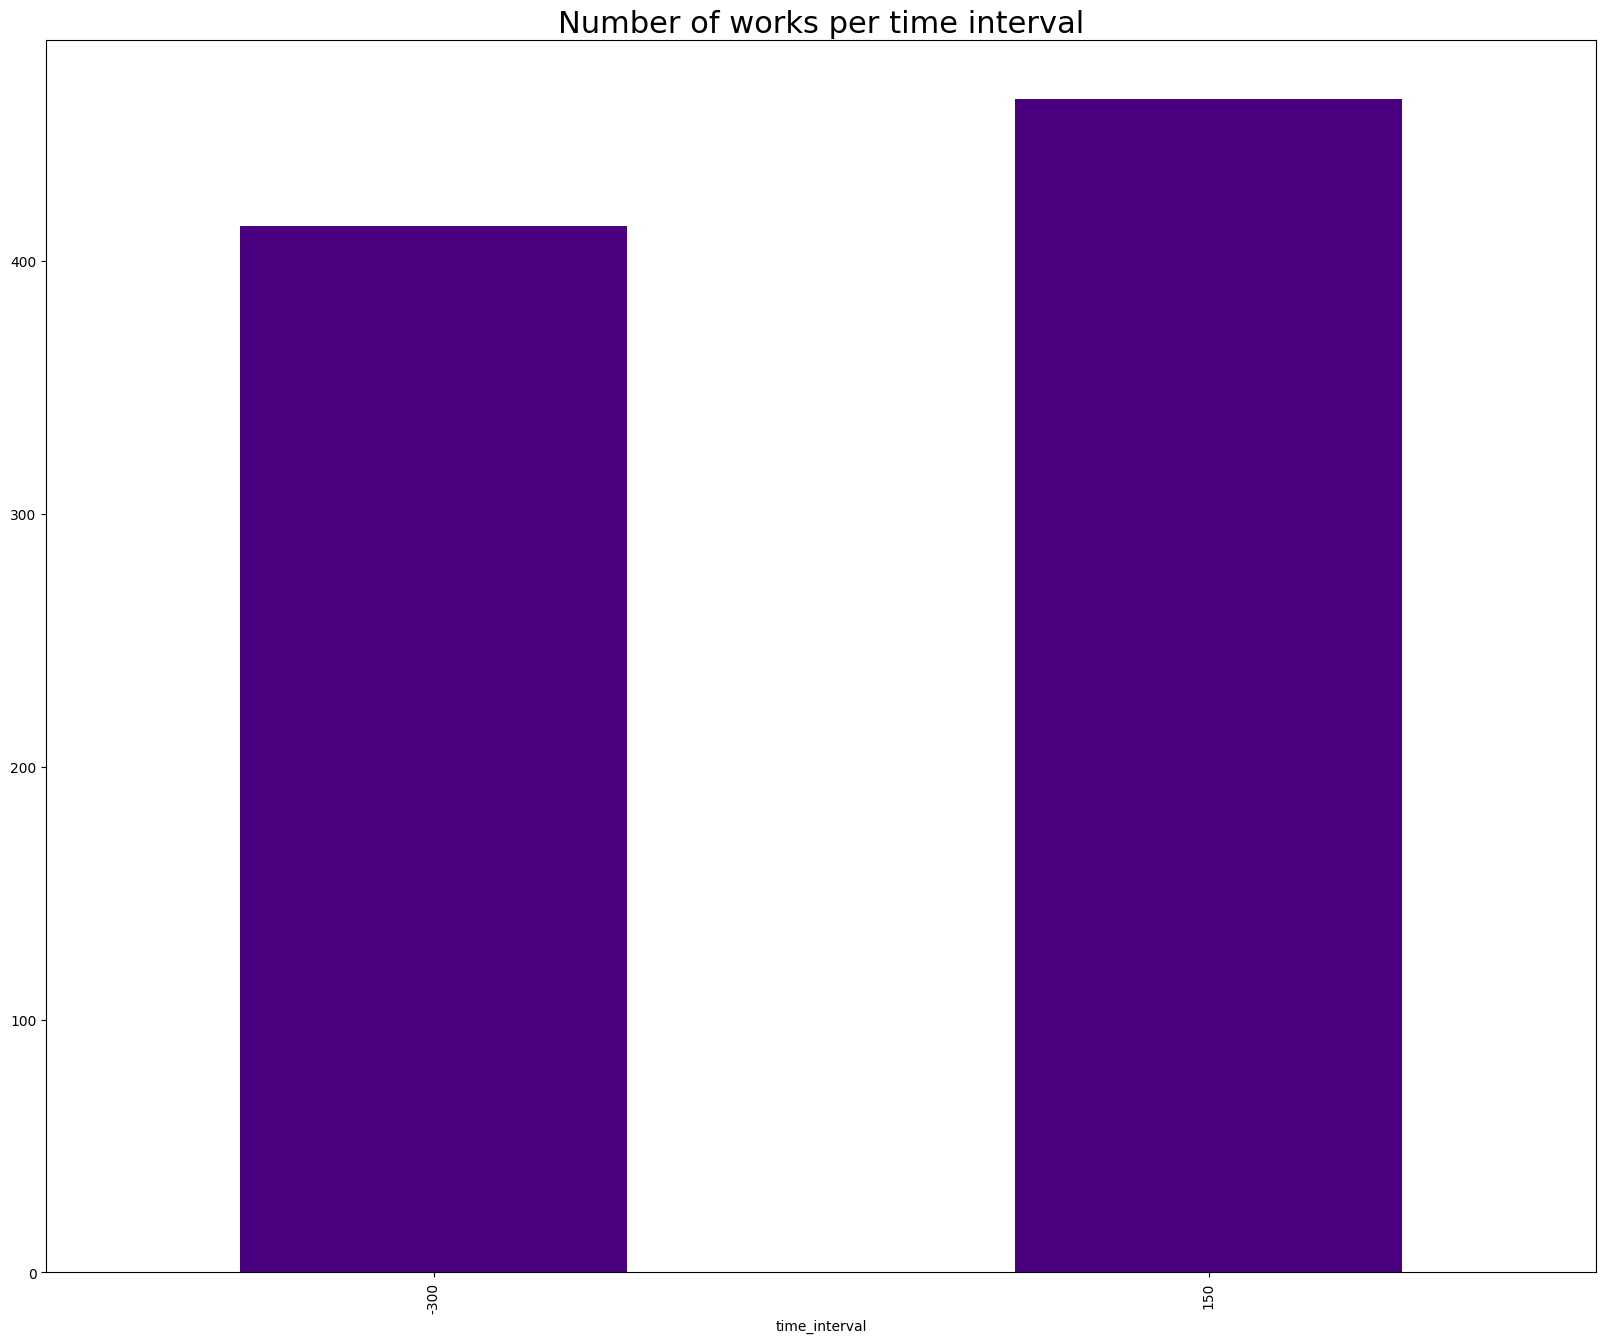

In [25]:
metadata_df0 = metadata_ph.groupby(['time_interval']).count()
metadata_df0 = metadata_df0['id']
ax = metadata_df0.plot(kind='bar', figsize=(20,16), color="indigo", fontsize=10);
ax.set_title("Number of works per time interval", fontsize=22)
plt.show()

### Define Christian vs non-Christian texts within second time slice (150-600 CE)

#### Christian subcorpus

Notes on which authors in IT corpus for Christian subcorpus (but should double-check if some texts need to be excluded within authors):

- 3rd century and earlier: Tertullian, Novatian, Minucius Felix, Arnobius, Lactantius, Commodian, Egeria
- 4-6th century: St Jerome, St Ambrose, St Augustine, Prudentius, Sedulius, Boethius (?), Sulpicius Severus, Prosper Aquitanus, Paulinus of Nola, Hydatius, Benedict of Nursia, Thomas of Edessa, Macarius of Alexandria, Eucherius of Lyon, Vincent de Lérins, Marcellinus Comes, Apophthegmata, Cassiodorus, Martin of Braga, Gregory of Tours, Isidore of Seville

Select Christian texts from IT:

In [26]:
tertullian = ['LAT0058', 'LAT0062','LAT0246', 'LAT0248', 'LAT0256', 'LAT0350', 'LAT0448', 'LAT0606', 'LAT0733', 'LAT0736', 'LAT0737', 'LAT0744', 'LAT0746', 'LAT0747', 'LAT0749', 'LAT0750', 'LAT0755', 'LAT0788']
novatian = ['LAT0865']
minucius_felix = ['LAT0267']
arnobius = ['LAT0264']
lactantius = ['LAT0268']
commodian = ['LAT0607']
egeria = ['LAT0719']
auctor_incertus_1 = ['LAT0471', 'LAT0203']
early_selected_texts = tertullian + novatian + minucius_felix + arnobius + lactantius + commodian + egeria + auctor_incertus_1
jerome1 = ['LAT0001', 'LAT0001_1', 'LAT0001_2', 'LAT0001_3', 'LAT0001_4', 'LAT0001_5', 'LAT0001_6', 'LAT0001_7', 'LAT0001_8', 'LAT0001_9', 'LAT0001_10', 'LAT0001_11', 'LAT0001_12', 'LAT0001_13', 'LAT0001_14', 'LAT0001_15', 'LAT0001_16', 'LAT0001_17', 'LAT0001_18', 'LAT0001_19', 'LAT0001_20', 'LAT0001_21', 'LAT0001_22', 'LAT0001_23', 'LAT0001_24', 'LAT0001_25', 'LAT0001_26', 'LAT0001_27', 'LAT0001_28', 'LAT0001_29', 'LAT0001_30', 'LAT0001_31', 'LAT0001_32', 'LAT0001_33', 'LAT0001_34', 'LAT0001_35']
jerome2 = ['LAT0001_36', 'LAT0001_37', 'LAT0001_38', 'LAT0001_39', 'LAT0001_40', 'LAT0001_41', 'LAT0001_42', 'LAT0001_43', 'LAT0001_44', 'LAT0001_45', 'LAT0001_46', 'LAT0001_47', 'LAT0001_48', 'LAT0001_49', 'LAT0001_50', 'LAT0001_51', 'LAT0001_52', 'LAT0001_53', 'LAT0001_54', 'LAT0001_55', 'LAT0001_56', 'LAT0001_57', 'LAT0001_58', 'LAT0001_59', 'LAT0001_60', 'LAT0001_61', 'LAT0001_62', 'LAT0001_63', 'LAT0001_64', 'LAT0001_65', 'LAT0001_66', 'LAT0001_67', 'LAT0001_68', 'LAT0001_69', 'LAT1039', 'LAT0726', 'LAT0843', 'LAT0878', 'LAT0880']
augustine = ['LAT0061', 'LAT0793', 'LAT0016', 'LAT0015', 'LAT0397', 'LAT0403', 'LAT0768']
ambrose = ['LAT0263', 'LAT0847']
paulinus_nola = ['LAT0609']
sulpicius_severus = ['LAT0612', 'LAT0410']
apophthegmata = ['LAT0978']
hydatius = ['LAT0775', 'LAT0776']
macarius_alex = ['LAT1004']
prudentius = ['LAT0270']
prosper_aquit = ['LAT0610']
sedulius = ['LAT0414']
eucherius_lyon = ['LAT0608']
vincent_lerins = ['LAT0904']
# boethius = ['LAT0917']
benedict_nursia = ['LAT0011']
cassiodorus = ['LAT0250', 'LAT0251', 'LAT0252', 'LAT0243', 'LAT0482']
thomas_edessa = ['LAT0875']
marcellinus_comes = ['LAT0791']
gregory_tours = ['LAT0783']
martin_braga = ['LAT0990', 'LAT0990_1', 'LAT0990_2', 'LAT0990_3', 'LAT0990_4', 'LAT0990_5', 'LAT0990_6', 'LAT0990_7', 'LAT0990_8', 'LAT0990_9']
isidore_seville = ['LAT0908', 'LAT0909', 'LAT0957']
auctor_incertus_2 = ['LAT0383']
late_selected_texts = jerome1 + jerome2 + augustine + ambrose + paulinus_nola + sulpicius_severus + apophthegmata + hydatius + macarius_alex + prudentius + prosper_aquit + sedulius + eucherius_lyon + vincent_lerins + benedict_nursia + cassiodorus + thomas_edessa + marcellinus_comes + gregory_tours + martin_braga + isidore_seville + auctor_incertus_2 # + boethius
selected_texts_1 = early_selected_texts + late_selected_texts
selected_texts_1 = ['IT-'+f for f in selected_texts_1]
selected_texts_1

['IT-LAT0058',
 'IT-LAT0062',
 'IT-LAT0246',
 'IT-LAT0248',
 'IT-LAT0256',
 'IT-LAT0350',
 'IT-LAT0448',
 'IT-LAT0606',
 'IT-LAT0733',
 'IT-LAT0736',
 'IT-LAT0737',
 'IT-LAT0744',
 'IT-LAT0746',
 'IT-LAT0747',
 'IT-LAT0749',
 'IT-LAT0750',
 'IT-LAT0755',
 'IT-LAT0788',
 'IT-LAT0865',
 'IT-LAT0267',
 'IT-LAT0264',
 'IT-LAT0268',
 'IT-LAT0607',
 'IT-LAT0719',
 'IT-LAT0471',
 'IT-LAT0203',
 'IT-LAT0001',
 'IT-LAT0001_1',
 'IT-LAT0001_2',
 'IT-LAT0001_3',
 'IT-LAT0001_4',
 'IT-LAT0001_5',
 'IT-LAT0001_6',
 'IT-LAT0001_7',
 'IT-LAT0001_8',
 'IT-LAT0001_9',
 'IT-LAT0001_10',
 'IT-LAT0001_11',
 'IT-LAT0001_12',
 'IT-LAT0001_13',
 'IT-LAT0001_14',
 'IT-LAT0001_15',
 'IT-LAT0001_16',
 'IT-LAT0001_17',
 'IT-LAT0001_18',
 'IT-LAT0001_19',
 'IT-LAT0001_20',
 'IT-LAT0001_21',
 'IT-LAT0001_22',
 'IT-LAT0001_23',
 'IT-LAT0001_24',
 'IT-LAT0001_25',
 'IT-LAT0001_26',
 'IT-LAT0001_27',
 'IT-LAT0001_28',
 'IT-LAT0001_29',
 'IT-LAT0001_30',
 'IT-LAT0001_31',
 'IT-LAT0001_32',
 'IT-LAT0001_33',
 'IT-LAT00

Notes on which authors in MQDQ corpus (but should double-check if some texts need to be excluded within authors):

Tertullian, Commodian, Lactantius, Laudes domini, Iuvencus, Proba, Marius Victorinus, Hilarius Pictaviensis, St Ambrose, Damasus, Prudentius, St Augustine, Paulinus of Nola, Pseudo Cyprian, Paulinus Pellaeus, Agrestius Gallus, Auspicius Tullensis, Carmen Sibyllinum, Cyprianus Gallus, Dracontius (partial), Paulinus Baeterrensis, Orientius, Paulinus Petricordiae, Prosper Aquitanus, Sedulius, Victorinus, Marius Victor, Sidonius Apollinaris, Ruricius Lemovicensis, Anonymous, Parthenius Africanus, Alcimus Avitus, Cyprianus Tolonensis, Remigius Remensis, Boethius (?), Ennodius, Arator, Flavius Cabilonensis, Marcus Casinensis, Rusticius Helpidius, Severus Malacitanus, Columba, Columbanus, Martin of Braga, Marius of Avenches, Isidor of Seville

Select Christian texts from MQDQ:

In [27]:
commodian = ['MQDQ-39', 'MQDQ-40', 'MQDQ-41']
tertullian = ['MQDQ-491', 'MQDQ-492']
lactantius = ['MQDQ-157', 'MQDQ-158', 'MQDQ-159']
laudes_dom = ['MQDQ-1']
iuvencus = ['MQDQ-151']
proba = ['MQDQ-350']
marius_vic = ['MQDQ-617']
hilarius_pic = ['MQDQ-117', 'MQDQ-118', 'MQDQ-119', 'MQDQ-120']
ambrose = ['MQDQ-179', 'MQDQ-180', 'MQDQ-181', 'MQDQ-182', 'MQDQ-183']
damasus = ['MQDQ-56']
prudentius = ['MQDQ-366', 'MQDQ-367', 'MQDQ-368', 'MQDQ-369', 'MQDQ-371', 'MQDQ-372', 'MQDQ-373', 'MQDQ-374', 'MQDQ-375']
augustine = ['MQDQ-512', 'MQDQ-513', 'MQDQ-514', 'MQDQ-515', 'MQDQ-516']
paulinus_nol = ['MQDQ-279', 'MQDQ-280', 'MQDQ-281', 'MQDQ-282']
pseud_cyp = ['MQDQ-379', 'MQDQ-380', 'MQDQ-381', 'MQDQ-382', 'MQDQ-383']
paulinus_pel = ['MQDQ-283', 'MQDQ-284']
agrestius_gal = ['MQDQ-66']
auspicius_tul = ['MQDQ-608']
carmen_sib = ['MQDQ-5']
cyprian_gal = ['MQDQ-48', 'MQDQ-49', 'MQDQ-50', 'MQDQ-51', 'MQDQ-52', 'MQDQ-53', 'MQDQ-54', 'MQDQ-55']
dracontius = ['MQDQ-59', 'MQDQ-60']
paulinus_bae = ['MQDQ-278']
orientius = ['MQDQ-242', 'MQDQ-243']
paulinus_pet = ['MQDQ-285', 'MQDQ-286', 'MQDQ-287']
prosper_aqu = ['MQDQ-360', 'MQDQ-361', 'MQDQ-362', 'MQDQ-363', 'MQDQ-364', 'MQDQ-365']
sedulius = ['MQDQ-422', 'MQDQ-423']
victorinus = ['MQDQ-564', 'MQDQ-565', 'MQDQ-566']
marius_vic = ['MQDQ-189']
sidonius = ['MQDQ-444', 'MQDQ-445']
ruricius_lem = ['MQDQ-111']
anonymous = ['MQDQ-140']
parthenius_afr = ['MQDQ-277']
alcimus_avi = ['MQDQ-622', 'MQDQ-623']
cyprianus_tol = ['MQDQ-621']
remigius_rem = ['MQDQ-618']
gildas = ['MQDQ-574', 'MQDQ-575']
# boethius = ['MQDQ-627', 'MQDQ-628']
ennodius = ['MQDQ-75', 'MQDQ-76', 'MQDQ-77', 'MQDQ-78', 'MQDQ-79', 'MQDQ-80', 'MQDQ-81', 'MQDQ-82', 'MQDQ-83', 'MQDQ-84', 'MQDQ-85', 'MQDQ-86']
arator = ['MQDQ-351', 'MQDQ-352', 'MQDQ-353', 'MQDQ-354', 'MQDQ-355']
flavius_cab = ['MQDQ-95']
marcus_cas = ['MQDQ-244']
rusticius_hel = ['MQDQ-415', 'MQDQ-416']
severus_mal = ['MQDQ-191']
columba = ['MQDQ-619']
columbanus = ['MQDQ-30', 'MQDQ-31', 'MQDQ-32', 'MQDQ-33', 'MQDQ-34', 'MQDQ-35']
martin_bra = ['MQDQ-209', 'MQDQ-210', 'MQDQ-211']
marius_ave = ['MQDQ-188']
isidore_sev = ['MQDQ-148']
selected_texts_2 = commodian + tertullian + lactantius + laudes_dom + iuvencus + proba + marius_vic + hilarius_pic + ambrose + damasus + prudentius + augustine + paulinus_nol + pseud_cyp + paulinus_pel + agrestius_gal + auspicius_tul + carmen_sib + cyprian_gal + dracontius + paulinus_bae + orientius + paulinus_pet + prosper_aqu + sedulius + victorinus + sidonius + ruricius_lem + anonymous + parthenius_afr + alcimus_avi + cyprianus_tol + remigius_rem + gildas + ennodius + arator + flavius_cab + marcus_cas + rusticius_hel + severus_mal + columba + columbanus + martin_bra + marius_ave + isidore_sev
selected_texts_2

['MQDQ-39',
 'MQDQ-40',
 'MQDQ-41',
 'MQDQ-491',
 'MQDQ-492',
 'MQDQ-157',
 'MQDQ-158',
 'MQDQ-159',
 'MQDQ-1',
 'MQDQ-151',
 'MQDQ-350',
 'MQDQ-189',
 'MQDQ-117',
 'MQDQ-118',
 'MQDQ-119',
 'MQDQ-120',
 'MQDQ-179',
 'MQDQ-180',
 'MQDQ-181',
 'MQDQ-182',
 'MQDQ-183',
 'MQDQ-56',
 'MQDQ-366',
 'MQDQ-367',
 'MQDQ-368',
 'MQDQ-369',
 'MQDQ-371',
 'MQDQ-372',
 'MQDQ-373',
 'MQDQ-374',
 'MQDQ-375',
 'MQDQ-512',
 'MQDQ-513',
 'MQDQ-514',
 'MQDQ-515',
 'MQDQ-516',
 'MQDQ-279',
 'MQDQ-280',
 'MQDQ-281',
 'MQDQ-282',
 'MQDQ-379',
 'MQDQ-380',
 'MQDQ-381',
 'MQDQ-382',
 'MQDQ-383',
 'MQDQ-283',
 'MQDQ-284',
 'MQDQ-66',
 'MQDQ-608',
 'MQDQ-5',
 'MQDQ-48',
 'MQDQ-49',
 'MQDQ-50',
 'MQDQ-51',
 'MQDQ-52',
 'MQDQ-53',
 'MQDQ-54',
 'MQDQ-55',
 'MQDQ-59',
 'MQDQ-60',
 'MQDQ-278',
 'MQDQ-242',
 'MQDQ-243',
 'MQDQ-285',
 'MQDQ-286',
 'MQDQ-287',
 'MQDQ-360',
 'MQDQ-361',
 'MQDQ-362',
 'MQDQ-363',
 'MQDQ-364',
 'MQDQ-365',
 'MQDQ-422',
 'MQDQ-423',
 'MQDQ-564',
 'MQDQ-565',
 'MQDQ-566',
 'MQDQ-444',
 'MQD

Merge Christian texts from IT and MQDQ:

In [28]:
selected_texts = selected_texts_1 + selected_texts_2
len(selected_texts)

267

Print christian metadata to csv:

In [29]:
metadata_ph_christian = metadata_ph[(metadata_ph['id'].isin(selected_texts))]
metadata_ph_christian
metadata_ph_christian.to_csv(os.path.join(dir_out, 'metadata_christian.csv'), index=None)

#### Non-Christian subcorpus

Select post 150 CE non-Christian texts by exclusion and display metadata:

In [30]:
metadata_ph_nonchristian = metadata_ph[(metadata_ph['time_interval']==150) & (~metadata_ph['id'].isin(selected_texts))]
metadata_ph_nonchristian

,id,title,creator,date,type,file,time_interval
421,IT-LAT0360,Noctes Atticae,"Gellius, Aulus",150,prose,lat_0150_IT-LAT0360.txt,150
422,IT-LAT0406,De nugis philosophorum,"Balbus, [Pseudo-] Caecilius",150,prose,lat_0150_IT-LAT0406.txt,150
423,IT-LAT0407,Quaestiones,"Caecilius Africanus, Sextus",150,prose,lat_0150_IT-LAT0407.txt,150
424,IT-LAT0916,De verbis dubiis,"Caper, Flavius",150,prose,lat_0150_IT-LAT0916.txt,150
425,MQDQ-223,carminum fragmenta,Annianus,150,poetry,lat_0150.0_MQDQ-223.txt,150
...,...,...,...,...,...,...,...
869,MQDQ-347,carmen in laudem Anastasii imperatoris,Priscianus,550,poetry,lat_0550.0_MQDQ-347.txt,150
870,MQDQ-348,carminis fragmentum,Priscianus,550,poetry,lat_0550.0_MQDQ-348.txt,150
871,MQDQ-346,perihegesis,Priscianus,550,poetry,lat_0550.0_MQDQ-346.txt,150
875,MQDQ-475,sylloge cod. Elnonensis,sylloge cod. Elnonensis,550,poetry,lat_0550.0_MQDQ-475.txt,150


In [31]:
nonchristian_selected_texts = list(metadata_ph_nonchristian['id'])
nonchristian_selected_texts

['IT-LAT0360',
 'IT-LAT0406',
 'IT-LAT0407',
 'IT-LAT0916',
 'MQDQ-223',
 'MQDQ-490',
 'MQDQ-240',
 'MQDQ-293',
 'MQDQ-345',
 'MQDQ-470',
 'MQDQ-465',
 'MQDQ-471',
 'MQDQ-467',
 'MQDQ-466',
 'MQDQ-469',
 'MQDQ-472',
 'MQDQ-468',
 'IT-LAT0043',
 'MQDQ-540',
 'IT-LAT0201',
 'IT-LAT0204',
 'IT-LAT0621',
 'IT-LAT0665',
 'IT-LAT0846',
 'IT-LAT0913',
 'IT-LAT0914',
 'MQDQ-123',
 'MQDQ-138',
 'MQDQ-234',
 'MQDQ-233',
 'MQDQ-232',
 'MQDQ-343',
 'MQDQ-344',
 'MQDQ-558',
 'IT-LAT0893',
 'IT-LAT0895',
 'IT-LAT0896',
 'IT-LAT0351',
 'MQDQ-107',
 'MQDQ-447',
 'MQDQ-87',
 'MQDQ-241',
 'MQDQ-290',
 'MQDQ-377',
 'MQDQ-378',
 'MQDQ-393',
 'MQDQ-499',
 'MQDQ-500',
 'MQDQ-563',
 'IT-LAT0886',
 'MQDQ-166',
 'MQDQ-149',
 'IT-LAT0115',
 'IT-LAT0233',
 'IT-LAT0238',
 'IT-LAT0286',
 'IT-LAT0353',
 'IT-LAT0361',
 'IT-LAT0362',
 'IT-LAT0364',
 'IT-LAT0365',
 'IT-LAT0366',
 'IT-LAT0367',
 'IT-LAT0850',
 'IT-LAT0919',
 'MQDQ-569',
 'MQDQ-570',
 'MQDQ-571',
 'MQDQ-573',
 'MQDQ-10',
 'MQDQ-609',
 'MQDQ-192',
 'MQDQ

## Make corpus and subcorpora

### Whole corpus

Define punctuation for stripping from corpus:

In [32]:
punctuation = ['.', ',', '...', ';', ':', '?', '(', ')', '-', '!', '[', ']', '"', "'", '""', '\n', '']

Append all files:

In [33]:
# Outputs a list of lists
# There is currenlty no lowercasing, but this can be added if preferred
corpus = list()
files_corpus = metadata_ph
for index, df_line in files_corpus.iterrows():
    sign = "+"
    if df_line['date'] < 0:
        sign = "-"
    file_name = df_line['file']
    # file = open(os.path.join(os.path.dirname(dir_in), "preprocessed_" + lemmas_or_tokens + "_2024", file_name), 'r')
    file = open(os.path.join(os.path.dirname(dir_in), "new_lemmatized_texts", file_name), 'r')
    while True:
        line = file.readline().strip()
        if line != "":
            corpus.append([token for token in line.split(" ") if token not in punctuation])
        if not line:
            break
    file.close()

### Time subcorpora

In [34]:
time2corpus = dict()

# Loop over all time intervals:
for t in range(n_intervals+1):
    files_corpus_t = metadata_ph.loc[metadata_ph['time_interval'] == intervals[t]]
    corpus_t = list()
    for index, df_line in files_corpus_t.iterrows():
        sign = "+"
        if df_line['date'] < 0:
            sign = "-"
        file_name = df_line['file']
        # file = open(os.path.join(os.path.dirname(dir_in), "preprocessed_" + lemmas_or_tokens + "_2024", file_name), 'r')
        file = open(os.path.join(os.path.dirname(dir_in), "new_lemmatized_texts", file_name), 'r')
        sentences_this_file = list()
        while True:
            line = file.readline().strip()
            if line != "":
                corpus_t.append([token for token in line.split(" ") if token not in punctuation])
            # if line is empty end of file is reached
            if not line:
                break
        file.close()
    time2corpus[t] = corpus_t

Check sentence and token balance between the two time slices:

In [35]:
# Number of sentences in the first time interval
len(time2corpus[0])

204522

In [36]:
# Number of words in the first time interval
num_words_int_0 = sum(len(i) for i in time2corpus[0])
num_words_int_0

3704745

In [37]:
# Number of sentences in the second time interval
len(time2corpus[1])

216777

In [38]:
# Number of words in the second time interval
num_words_int_1 = sum(len(i) for i in time2corpus[1])
num_words_int_1

3110871

In [39]:
# Sentence count ratio
len(time2corpus[0])/len(time2corpus[1])

0.9434672497543558

In [40]:
# Word count ratio
num_words_int_0/num_words_int_1

1.1909028050343458

### (Non-)Christian subcorpora

In [41]:
corpus_christi = list()
files_corpus_christi = metadata_ph_christian
for index, df_line in files_corpus_christi.iterrows():
    sign = "+"
    if df_line['date'] < 0:
        sign = "-"
    file_name = df_line['file']
    # file = open(os.path.join(os.path.dirname(dir_in), "preprocessed_" + lemmas_or_tokens + "_2024", file_name), 'r')
    file = open(os.path.join(os.path.dirname(dir_in), "new_lemmatized_texts", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            corpus_christi.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_christi.append(sentences_this_file)

In [42]:
corpus_non_christi = list()
files_corpus_non_christi = metadata_ph_nonchristian
for index, df_line in files_corpus_non_christi.iterrows():
    sign = "+"
    if df_line['date'] < 0:
        sign = "-"
    file_name = df_line['file'] 
    # file = open(os.path.join(os.path.dirname(dir_in), "preprocessed_" + lemmas_or_tokens + "_2024", file_name), 'r')
    file = open(os.path.join(os.path.dirname(dir_in), "new_lemmatized_texts", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            corpus_non_christi.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_non_christi.append(sentences_this_file)

Check sentence and token balance between the two subcorpora:

In [43]:
len(corpus_christi)

98274

In [44]:
num_words_corpus_christi = sum(len(i) for i in corpus_christi)
num_words_corpus_christi

1740382

In [45]:
len(corpus_non_christi)

118505

In [46]:
num_words_corpus_non_christi = sum(len(i) for i in corpus_non_christi)
num_words_corpus_non_christi

1370489

In [47]:
len(corpus_christi)/len(corpus_non_christi)

0.8292814649170921

In [47]:
num_words_corpus_christi/num_words_corpus_non_christi

1.2698985544575696

## Pre-trained LatinBERT 

### Calculate or load embeddings

Remember to set `rebuild` to `True` if this is your first run, or to `False` if it is a subsequent run. If this is your first run, you can expect this section to take a few hours.

Define bert and tokenizer models paths. I set these so that they reach the installed Latin BERT models on the GitHub folder on your machine, but feel free to change them if that does not work out or if you installed Latin BERT elsewhere.

In [ ]:
github_dir = os.path.abspath(os.path.join(dir_in, "..", ".."))
tokenizer_path = os.path.join(os.path.dirname(github_dir), "latin-bert", "models", "subword_tokenizer_latin", "latin.subword.encoder")
bert_path = os.path.join(os.path.dirname(github_dir), "latin-bert", "models", "latin_bert")

First time slice (300 BCE to 150 CE):

In [65]:
bert_sents_t0 = calculate_or_load_embeddings(time2corpus[0], dir_out, "bert_t0_results.pickle", rebuild, tokenizer_path, bert_path)

Second time slice (150 to 600 CE):

In [66]:
bert_sents_t1 = calculate_or_load_embeddings(time2corpus[1], dir_out, "bert_t1_results.pickle", rebuild, tokenizer_path, bert_path)

Christian subcorpus:

In [ ]:
bert_sents_christi = calculate_or_load_embeddings(corpus_christi, dir_out, "bert_christi_results.pickle", rebuild, tokenizer_path, bert_path)

: 

Non-christian subcorpus:

In [ ]:
bert_sents_non_christi = calculate_or_load_embeddings(corpus_non_christi, dir_out, "bert_non_christi_results.pickle", rebuild, tokenizer_path, bert_path)

Check how many sentences were chopped off (result: 2 if `max_seq_length=512`, 13 if `max_seq_length=256`)

In [72]:
# Function to check if any sentence in the corpus is longer than the maximum sequence length
def check_sentence_lengths(corpus, max_length):
    count = 0
    for i, sentence in enumerate(corpus):
        # Flatten the sentence into a single string and tokenize it
        flattened_sentence = ' '.join(sentence)
        tokens = flattened_sentence.split()  # Assuming tokens are separated by spaces
        if len(tokens) > max_length:
            print(f"Sentence {i} is longer than {max_length} tokens with {len(tokens)} tokens.")
            count += 1
    return count

# Corpus variables are: time2corpus[0], time2corpus[1], corpus_christi, corpus_non_christi, corpus
max_seq_length = 256
long_sentences_count = check_sentence_lengths(corpus, max_seq_length)
if long_sentences_count > 0:
    print(f"There are {long_sentences_count} sentences longer than the maximum sequence length.")
else:
    print("All sentences are within the maximum sequence length.")

Sentence 22667 is longer than 256 tokens with 619 tokens.
Sentence 34646 is longer than 256 tokens with 270 tokens.
Sentence 51519 is longer than 256 tokens with 282 tokens.
Sentence 53506 is longer than 256 tokens with 296 tokens.
Sentence 72083 is longer than 256 tokens with 333 tokens.
Sentence 98546 is longer than 256 tokens with 272 tokens.
Sentence 116496 is longer than 256 tokens with 295 tokens.
Sentence 231536 is longer than 256 tokens with 295 tokens.
Sentence 297924 is longer than 256 tokens with 633 tokens.
Sentence 319297 is longer than 256 tokens with 319 tokens.
Sentence 325183 is longer than 256 tokens with 360 tokens.
Sentence 346198 is longer than 256 tokens with 257 tokens.
Sentence 415540 is longer than 256 tokens with 281 tokens.
There are 13 sentences longer than the maximum sequence length.


### Average embeddings per lemma

Starting with the first time slice:

In [67]:
average_embeddings_t0, most_frequent_words_t0 = average_embeddings_per_lemma(bert_sents_t0, dir_out, "average_embeddings_t0.pickle", rebuild)

Word: [CLS]
Embedding: [-4.60114889e-02 -3.62564206e-01  5.49348891e-01  1.22916333e-01
 -1.44381940e-01 -6.66354597e-01  6.79234192e-02 -6.10374391e-01
  5.80262346e-03 -1.64340958e-01  8.90210178e-03  9.06180367e-02
 -1.10604629e-01 -2.57016361e-01  9.54084545e-02  9.28911388e-01
  3.40409391e-02 -2.05194548e-01 -7.12134182e-01  1.27022171e+00
 -2.85356104e-01  2.42955089e-02  2.48551831e-01 -1.02982193e-01
  2.39402860e-01 -1.28839418e-01 -3.74812156e-01  3.04984838e-01
  8.78362298e-01 -7.23417774e-02  1.28157675e-01  1.28419772e-01
 -8.05647671e-02 -1.06569864e-01 -2.13113934e-01 -1.23228230e-01
 -1.48190126e-01 -1.29407883e-01  6.25263214e-01  6.25228763e-01
 -3.16276163e-01 -1.55186979e-04 -4.92706805e-01 -2.00202346e-01
 -1.26636282e-01 -3.12106341e-01  1.98306039e-01 -2.94990987e-01
 -3.96175802e-01  1.40486255e-01 -2.48890430e-01  4.11478691e-02
 -2.57558320e-02 -2.97881197e-02  7.31831074e-01 -2.67710745e-01
  7.17069089e-01  1.06925093e-01  1.25828693e-02 -2.62539610e-02
 -

And following with the second time slice:

In [68]:
average_embeddings_t1, most_frequent_words_t1 = average_embeddings_per_lemma(bert_sents_t1, dir_out, "average_embeddings_t1.pickle", rebuild)

Word: [CLS]
Embedding: [-9.35779959e-02 -1.66758910e-01  5.36056757e-01  8.68483796e-04
 -1.80266455e-01 -6.43536091e-01  6.00244291e-02 -5.45454085e-01
 -7.69227520e-02 -2.23879963e-01 -6.18125387e-02  9.18792039e-02
 -7.91051164e-02 -1.73203811e-01  7.24772662e-02  7.49313176e-01
  2.58544721e-02 -1.62960321e-01 -6.04234695e-01  1.21585608e+00
 -2.73976773e-01  1.29358828e-01  1.78855360e-02 -2.47846320e-01
  9.77508426e-02 -1.91559836e-01 -4.83196676e-01  1.78521886e-01
  1.03317773e+00 -8.64713565e-02  2.25136406e-03  9.77719724e-02
 -1.49058765e-02 -1.75697774e-01 -5.46602234e-02  5.24804881e-03
 -2.55502850e-01 -1.50474951e-01  5.48890233e-01  5.31971753e-01
 -3.69035453e-01  1.05820812e-01 -2.95609862e-01 -1.85824051e-01
 -6.11817501e-02 -2.43069991e-01  2.00262129e-01 -2.47096390e-01
 -1.74787909e-01  2.57600471e-02 -2.75934219e-01 -1.42564654e-01
 -2.57692076e-02 -6.35809153e-02  6.17878556e-01 -3.33741933e-01
  7.32005894e-01  1.10405058e-01 -1.27348214e-01  3.93750370e-02
 -

Sanity check: print the 500 most common words in t0

In [ ]:
# Dictionary to store embeddings for each word type
word_embeddings = defaultdict(list)
    
# Collect all embeddings for each word type and count word frequencies
word_counter = Counter()
for sent in bert_sents_t0:
    for lemma, embedding in sent:
        word_embeddings[lemma].append(embedding)
        word_counter[lemma] += 1

# Get the 500 most frequent words
most_frequent_words_t0_2 = [word for word, _ in word_counter.most_common(500)]

# Print the embeddings for the ten most frequent words
for word in most_frequent_words_t0_2:
    print(f"Word: {word}")

Word: [CLS]
Word: [SEP]
Word: sum
Word: qui
Word: et
Word: in
Word: que
Word: is
Word: hic
Word: non
Word: ut
Word: cum
Word: ad
Word: ego
Word: ille
Word: tu
Word: ab
Word: atque
Word: neque
Word: si
Word: omnis
Word: sed
Word: sui
Word: res
Word: facio
Word: possum
Word: dico
Word: quis
Word: ex
Word: ipse
Word: aut
Word: suus
Word: quam
Word: uideo
Word: de
Word: habeo
Word: per
Word: iam
Word: do
Word: etiam
Word: ne
Word: meus
Word: alius
Word: enim
Word: idem
Word: quod
Word: pars
Word: magnus
Word: animus
Word: uolo
Word: tamen
Word: -ne
Word: homo
Word: nam
Word: unus
Word: nunc
Word: tuus
Word: multus
Word: locus
Word: causa
Word: bellum
Word: nihil
Word: romanus
Word: noster
Word: dies
Word: quidem
Word: ita
Word: nos
Word: quoque
Word: tum
Word: fero
Word: ago
Word: nullus
Word: autem
Word: uenio
Word: pater
Word: magis
Word: tempus
Word: inter
Word: primus
Word: urbs
Word: hostis
Word: ubi
Word: uir
Word: sic
Word: quidam
Word: corpus
Word: deus
Word: uis
Word: consul
Word:

The Christian subcorpus:

In [ ]:
average_embeddings_christi, most_frequent_words_christi = average_embeddings_per_lemma(bert_sents_christi, dir_out, "average_embeddings_christi.pickle", rebuild)

Word: [CLS]
Embedding: [-1.71179160e-01 -1.53440058e-01  5.79170644e-01  4.08106260e-02
 -1.07168011e-01 -7.78233767e-01  1.14785679e-01 -6.31309509e-01
 -1.37912899e-01 -3.01552624e-01 -6.46168515e-02  1.29035518e-01
  5.67715615e-04 -3.38618249e-01  7.41724819e-02  9.18249726e-01
  1.21704809e-01 -2.19046548e-01 -6.52269900e-01  1.15375030e+00
 -2.82567143e-01  1.24999598e-01  1.06742643e-01 -2.33100116e-01
  1.25452906e-01 -1.29069984e-01 -5.35463095e-01  2.73219466e-01
  9.52127457e-01 -1.87278196e-01 -6.79843575e-02  7.33643323e-02
 -1.62764162e-01 -1.83032267e-02 -1.52073145e-01  9.83309820e-02
 -1.73837781e-01 -1.37078702e-01  6.68175995e-01  5.40052950e-01
 -4.26088065e-01 -1.98763907e-02 -4.54027712e-01 -1.64981365e-01
 -2.50753671e-01 -2.93294936e-01  1.86398610e-01 -2.12340325e-01
 -3.38330120e-01  7.69690946e-02 -3.33175361e-01  1.51169708e-03
 -4.21759635e-02  4.73740278e-03  6.04271650e-01 -3.52202594e-01
  6.45460069e-01  1.26718193e-01 -9.05298740e-02  5.47439232e-02
 -

And the non-Christian one:

In [ ]:
average_embeddings_non_christi, most_frequent_words_non_christi = average_embeddings_per_lemma(bert_sents_non_christi, dir_out, "average_embeddings_non_christi.pickle", rebuild)

Word: [CLS]
Embedding: [-2.65081022e-02 -1.78292081e-01  4.98611301e-01 -3.36571857e-02
 -2.43419021e-01 -5.27267218e-01  1.26687074e-02 -4.71106976e-01
 -2.42173113e-02 -1.56858757e-01 -5.93843609e-02  5.97686470e-02
 -1.47965938e-01 -3.01477015e-02  7.09861666e-02  6.03116155e-01
 -5.69988042e-02 -1.14537954e-01 -5.62955499e-01  1.26992786e+00
 -2.66430587e-01  1.33163378e-01 -5.89173436e-02 -2.60609627e-01
  7.38381520e-02 -2.45589077e-01 -4.38039571e-01  9.66517404e-02
  1.10287857e+00  6.56184624e-04  6.29604086e-02  1.18877456e-01
  1.12906985e-01 -3.11746091e-01  2.95063239e-02 -7.52097070e-02
 -3.25943351e-01 -1.62102506e-01  4.46003586e-01  5.24967253e-01
 -3.19460392e-01  2.14473307e-01 -1.58596113e-01 -2.03841865e-01
  1.02685057e-01 -1.99798927e-01  2.12215587e-01 -2.77134597e-01
 -3.33112516e-02 -1.84925869e-02 -2.26373330e-01 -2.67095476e-01
 -1.15870507e-02 -1.22632749e-01  6.30003691e-01 -3.17893177e-01
  8.06861937e-01  9.63155776e-02 -1.59176663e-01  2.60969289e-02
 -

#### Cosine similarity for averaged embeddings

Now find cosine similarity between the averaged vectors of (1) t0 and t1 and (2) corpus_christi and corpus_non_christi.

In [ ]:
# Compute cosine similarity for each token that appears in both t0 and t1
cosine_similarities_t0t1 = {}
for token in average_embeddings_t0:
    if token in average_embeddings_t1:
        embedding_t0 = average_embeddings_t0[token].reshape(1, -1)
        embedding_t1 = average_embeddings_t1[token].reshape(1, -1)
        similarity = cosine_similarity(embedding_t0, embedding_t1)[0][0]
        cosine_similarities_t0t1[token] = similarity

# Print the cosine similarities for each token
for token, similarity in cosine_similarities_t0t1.items():
    print(f"Token: {token}, Cosine Similarity: {similarity}")

Token: [CLS], Cosine Similarity: 0.9820024967193604
Token: amicus, Cosine Similarity: 0.9941995143890381
Token: cum, Cosine Similarity: 0.9944712519645691
Token: uideo, Cosine Similarity: 0.995359480381012
Token: obliuiscor, Cosine Similarity: 0.9848413467407227
Token: miseria, Cosine Similarity: 0.9807164669036865
Token: inimicus, Cosine Similarity: 0.9772108197212219
Token: si, Cosine Similarity: 0.9904782772064209
Token: sum, Cosine Similarity: 0.9938517212867737
Token: comminiscor, Cosine Similarity: 0.9834445714950562
Token: neque, Cosine Similarity: 0.9930635690689087
Token: libens, Cosine Similarity: 0.9943409562110901
Token: aeque, Cosine Similarity: 0.968783974647522
Token: [SEP], Cosine Similarity: 0.9714990258216858
Token: postremus, Cosine Similarity: 0.991248607635498
Token: dico, Cosine Similarity: 0.9838836193084717
Token: primus, Cosine Similarity: 0.993690013885498
Token: taceo, Cosine Similarity: 0.9925438165664673
Token: apud, Cosine Similarity: 0.987410843372345
Tok

In [ ]:
# Write the cosine similarities to a CSV file
cosine_sim_csv = os.path.join(dir_out, "cosine_similarities_t0t1.csv")

with open(cosine_sim_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "Cosine Similarity"])  # Write the header
    for token, similarity in cosine_similarities_t0t1.items():
        writer.writerow([token, similarity])

print(f"Cosine similarities saved to {cosine_sim_csv}")

: 

In [ ]:
# Compute cosine similarity for each token that appears in both sets of embeddings
cosine_similarities_christi_nonchristi = {}
for token in average_embeddings_christi:
    if token in average_embeddings_non_christi:
        embedding_christi = average_embeddings_christi[token].reshape(1, -1)
        embedding_non_christi = average_embeddings_non_christi[token].reshape(1, -1)
        similarity = cosine_similarity(embedding_christi, embedding_non_christi)[0][0]
        cosine_similarities_christi_nonchristi[token] = similarity
# Print the cosine similarities for each token
for token, similarity in cosine_similarities_christi_nonchristi.items():
    print(f"Token: {token}, Cosine Similarity: {similarity}")

Token: [CLS], Cosine Similarity: 0.955303430557251
Token: cogito, Cosine Similarity: 0.9880996346473694
Token: ego, Cosine Similarity: 0.9808539748191833
Token: et, Cosine Similarity: 0.9819984436035156
Token: cum, Cosine Similarity: 0.99466872215271
Token: animus, Cosine Similarity: 0.9948762059211731
Token: meus, Cosine Similarity: 0.9479955434799194
Token: octavius, Cosine Similarity: 0.9119018316268921
Token: bonus, Cosine Similarity: 0.9669083952903748
Token: fidelis, Cosine Similarity: 0.9788211584091187
Token: contubernalis, Cosine Similarity: 0.8865160346031189
Token: memoria, Cosine Similarity: 0.9789780974388123
Token: recenseo, Cosine Similarity: 0.9831531643867493
Token: tantus, Cosine Similarity: 0.9905210733413696
Token: dulcedo, Cosine Similarity: 0.980341911315918
Token: adfectio, Cosine Similarity: 0.9134397506713867
Token: homo, Cosine Similarity: 0.9825067520141602
Token: inhaeresco, Cosine Similarity: 0.9598866701126099
Token: ut, Cosine Similarity: 0.99271148443222

In [ ]:
# Write the cosine similarities to a CSV file
cosine_sim_csv = os.path.join(dir_out, "cosine_similarities_christi_nonchristi.csv")

with open(cosine_sim_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "Cosine Similarity"])  # Write the header
    for token, similarity in cosine_similarities_christi_nonchristi.items():
        writer.writerow([token, similarity])

print(f"Cosine similarities saved to {cosine_sim_csv}")

Cosine similarities saved to /Users/valentinalunardi/Documents/UCLA_PhD/Thesis/Metadata_corrections/bert_tests/output/cosine_similarities_christi_nonchristi.csv


Check neighbours for some of the words in the various subcorpora:

In [69]:
neighbors = find_neighbors("deus", average_embeddings_t0, top_k=10)
print(neighbors)

[('iuppiter', 0.8974618), ('dea', 0.8915237), ('apollo', 0.8491823), ('deo', 0.8443942), ('sacerdos', 0.8430897), ('tyrannus', 0.84169424), ('locus', 0.8357646), ('sacer', 0.83372617), ('dis', 0.8322133), ('homo', 0.8302711)]


In [70]:
neighbors = find_neighbors("deus", average_embeddings_t1, top_k=10)
print(neighbors)

[('iuppiter', 0.8541002), ('dea', 0.84677154), ('dominus', 0.8351222), ('chaldeus', 0.8336737), ('christus', 0.8321691), ('creator', 0.8254372), ('semideus', 0.8251782), ('photideus', 0.8208175), ('iesus', 0.8197284), ('deo', 0.8158668)]


In [ ]:
neighbors = find_neighbors("deus", average_embeddings_christi, top_k=10)
print(neighbors)

[('iuppiter', 0.8509733), ('dea', 0.84237814), ('divinitas', 0.8379198), ('dominus', 0.83479184), ('christus', 0.8264352), ('creator', 0.8196183), ('iesus', 0.81863475), ('magister', 0.8113408), ('caesar', 0.8108454), ('imperator', 0.8103151)]


In [ ]:
neighbors = find_neighbors("deus", average_embeddings_non_christi, top_k=10)
print(neighbors)

In [ ]:
neighbors = find_neighbors("virtus", average_embeddings_t0, top_k=10)
print(neighbors)

[('bonitas', 0.91908383), ('laus', 0.9119155), ('fortitudo', 0.907141), ('uirtus', 0.9062594), ('dignitas', 0.90126324), ('voluntas', 0.9005522), ('gravitas', 0.9004375), ('felicitas', 0.8999058), ('justitia', 0.89976203), ('humanitas', 0.8982957)]


In [ ]:
neighbors = find_neighbors("virtus", average_embeddings_t1, top_k=10)
print(neighbors)

[('uirtus', 0.9155493), ('bonitas', 0.9129449), ('potentia', 0.90705955), ('felicitas', 0.90673584), ('laus', 0.905445), ('magnitudo', 0.9026704), ('operatio', 0.90078086), ('sanctitas', 0.90054286), ('ars', 0.8963341), ('divinitas', 0.89580345)]


#### TODO: think about other ways to measure similarity:

I think it might be common to use inverted cosine similarity these days, judging from some papers, but we need to look into this. It's referred to as PRT (inverted cosine similarity over word prototypes) – the word prototypes being the averaged embeddings in the separate time frames.

There is also something known as APD (average pairwise cosine distance), which I think might avoid averaging of embeddings, or rather does averaging of cosine distances calculated for each pair of embeddings across the two sets.

### Cluster embeddings, whole corpus

In principle clustering embeddings would allow us to detect different word senses (for each word type, a cluster corresponds to a sense, and there should technically be one cluster per meaning, though see https://doi.org/10.3384/nejlt.2000-1533.2022.3478). However, there are a few issues with clustering, summarized as follows:
- We can set the number of cluster to be found for each word arbitrarily: this will likely not correspond to the number of senses each word has, but it might make it easier to deal with word similarity measurement. (Still, not ideal.)
- If we instead optimize the number of clusters for each word, the number of clusters/senses might not to be the same for a single word across different time slices or subcorpora, meaning comparison is more difficult (i.e. what are we comparing? should one do pairwise comparison or something else?)
- Something we could try and adapt for this second option (but not sure) is the code from Giulianelli et al. (2020): https://github.com/glnmario/cwr4lsc/tree/master. However, keep in mind that the structure of bert_sents is different from what they set up, so we need to modify bert_sents to make it look like their `usages` dictionary, or otherwise make their clustering code work with the bert_sents structure.

These are issues that need to be addressed before moving forward, but below are some tests.

TODO: we need to figure out what counts as a cluster. (1) maybe we need to set some kind of minimum threshold, if `kmeans` does not deal with that (if there are, say, two rogue embeddings that are close together but far from a cluster, do those count as a separate sense or are they just rogue?) (2) I am assuming `kmeans` does not make the clusters be of the same size (we would just want them to be of whatever size makes sense, save for the min threshold), but this should be checked. Obviously this ties into the issue about how many clusters there should be.

The following few cells find 3 clusters for each word type in both t0 and t1.

In [ ]:
clustered_embeddings_t0 = cluster_embeddings(bert_sents_t0, dir_out, "clustered_embeddings_t0.pickle", rebuild)

Word: [CLS]
Sense 1 Embedding: [-1.25756100e-01 -4.93722081e-01  5.22034943e-01  2.21602395e-02
 -2.03289196e-01 -5.65766156e-01  1.45448238e-01 -6.58564627e-01
  3.60269435e-02 -2.87479937e-01  5.41991852e-02  1.78496838e-01
 -8.72996449e-03 -3.11591238e-01 -8.84756446e-06  1.11982191e+00
  3.08636397e-01 -3.20631236e-01 -6.64408863e-01  1.07178509e+00
 -1.95807070e-01  3.76038291e-02  2.10307151e-01 -8.27668086e-02
  2.11739212e-01 -3.10842395e-01 -3.86687875e-01  4.02170748e-01
  1.03872323e+00 -1.88013792e-01  1.21170804e-01 -3.70801389e-02
  3.08108702e-02  9.93575305e-02  1.32057741e-02 -3.74553949e-01
 -1.74130827e-01 -1.92849919e-01  6.83271050e-01  8.21870327e-01
 -2.80921608e-01 -8.25849026e-02 -5.04446507e-01 -3.10347915e-01
 -1.85684383e-01 -3.23001981e-01  1.13745630e-02 -2.59753615e-01
 -4.84023482e-01  2.43933037e-01 -2.03776225e-01 -3.36390659e-02
 -1.25155091e-01  1.95958152e-01  6.36988461e-01 -4.30013686e-01
  7.68194795e-01  1.09451324e-01  7.14084432e-02 -9.3177259

In [ ]:
# Playing with cosine similarity between senses to see if the clusters make sense
for word, embeddings in list(clustered_embeddings_t0.items())[:10]:  # Print the first 10 words and their clustered embeddings
    print(f"Word: {word}")
    if len(embeddings) > 2:
        print(f"Cosine similarity between sense 1 and sense 2: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[1].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 1 and sense 3: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 2 and sense 3: {cosine_similarity(embeddings[1].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
    print()

Word: [CLS]
Cosine similarity between sense 1 and sense 2: 0.942766547203064
Cosine similarity between sense 1 and sense 3: 0.918454647064209
Cosine similarity between sense 2 and sense 3: 0.9260931015014648

Word: amicus
Cosine similarity between sense 1 and sense 2: 0.9330623149871826
Cosine similarity between sense 1 and sense 3: 0.8843738436698914
Cosine similarity between sense 2 and sense 3: 0.9534257650375366

Word: cum
Cosine similarity between sense 1 and sense 2: 0.9119113087654114
Cosine similarity between sense 1 and sense 3: 0.9649457335472107
Cosine similarity between sense 2 and sense 3: 0.9428434371948242

Word: video
Cosine similarity between sense 1 and sense 2: 0.8652307987213135
Cosine similarity between sense 1 and sense 3: 0.8805232644081116
Cosine similarity between sense 2 and sense 3: 0.8930837512016296

Word: obliuiscere

Word: miseria
Cosine similarity between sense 1 and sense 2: 0.8994755744934082
Cosine similarity between sense 1 and sense 3: 0.93223696947

In [ ]:
# More playing
from scipy.spatial.distance import cosine
most_different_score = 0
most_different = None
for word, embeddings in list(clustered_embeddings_t0.items())[:]:  # Print the first 10 words and their clustered embeddings
    print(f"Word: {word}")
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            score = cosine(embeddings[i], embeddings[j])
            if score > most_different_score:
                most_different_score = score
                most_different = word
print(f"Most different senses: {most_different}, {most_different_score}")

Word: [CLS]
Word: amicus
Word: cum
Word: video
Word: obliuiscere
Word: miseria
Word: inimicus
Word: si
Word: sum
Word: commentus
Word: nec
Word: libet
Word: aequus
Word: [SEP]
Word: postremus
Word: dico#2
Word: primus
Word: taceo
Word: apud
Word: latinus
Word: marcius
Word: vates
Word: praeceptum
Word: compono
Word: ex
Word: quis#2
Word: ille
Word: postr
Word: tac
Word: ne
Word: ningulus
Word: mederi
Word: queo
Word: nullus
Word: hic
Word: unus
Word: plurimus
Word: consentio
Word: gens
Word: populus
Word: primarius
Word: vir
Word: pulices
Word: -ne
Word: an
Word: cimices
Word: pes
Word: respondeo
Word: ego
Word: corruo
Word: quasi
Word: iacio
Word: secena
Word: sicine
Word: hau
Word: multus
Word: secus
Word: ornamentum
Word: incedo
Word: gnobiles
Word: ignobilis
Word: affatim
Word: edi
Word: bibo
Word: ludo
Word: uecorde
Word: et
Word: maleficum
Word: vacerra
Word: lepus
Word: tueor
Word: pulpamentum
Word: quaero
Word: meus
Word: puera
Word: uerbi
Word: tuus
Word: os#1
Word: supra
Word

In [ ]:
clustered_embeddings_t1 = cluster_embeddings(bert_sents_t1, dir_out, "clustered_embeddings_t1.pickle", rebuild)

Word: [CLS]
Sense 1 Embedding: [-3.28155272e-02 -9.68932286e-02  4.70559627e-01 -2.20046967e-01
 -4.36426699e-01 -2.55030274e-01 -4.97259408e-01 -3.73791993e-01
 -4.81661856e-01 -3.28730166e-01 -2.55442590e-01 -5.27098253e-02
 -2.77615070e-01  3.29921186e-01  1.44626379e-01  6.28040433e-02
 -1.30719677e-01 -9.85193253e-02 -1.38778239e-01  1.31492388e+00
 -7.05574900e-02  6.12993062e-01 -4.61387306e-01 -3.77296865e-01
  3.69384199e-01 -3.57992023e-01 -5.08750319e-01  1.51448801e-01
  1.14674962e+00  1.37122959e-01 -4.64557052e-01  2.21610278e-01
 -7.76234567e-02 -6.70050383e-01  4.54627275e-01 -1.24582469e-01
 -5.33345997e-01 -2.53015816e-01  2.73059934e-01  4.46282923e-01
 -3.18560988e-01  2.94397593e-01  3.56870890e-01  7.17332214e-02
  2.79694527e-01 -3.43527317e-01  3.74500662e-01 -3.97297263e-01
  5.54424286e-01  2.76780128e-02 -2.00631768e-01 -1.02686274e+00
  1.41334802e-01  1.40460171e-02  4.05559242e-01 -5.50663888e-01
  8.94404709e-01  1.89514816e-01 -4.74483788e-01 -1.7930147

In [ ]:
# Playing with cosine similarity between senses to see if the clusters make sense
for word, embeddings in list(clustered_embeddings_t1.items())[:10]:
    print(f"Word: {word}")
    if len(embeddings) > 2:
        print(f"Cosine similarity between sense 1 and sense 2: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[1].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 1 and sense 3: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 2 and sense 3: {cosine_similarity(embeddings[1].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
    print()

Word: [CLS]
Cosine similarity between sense 1 and sense 2: 0.8205375075340271
Cosine similarity between sense 1 and sense 3: 0.7972675561904907
Cosine similarity between sense 2 and sense 3: 0.7657284736633301

Word: cogito
Cosine similarity between sense 1 and sense 2: 0.9469366669654846
Cosine similarity between sense 1 and sense 3: 0.9651336073875427
Cosine similarity between sense 2 and sense 3: 0.9611691832542419

Word: ego
Cosine similarity between sense 1 and sense 2: 0.9394918084144592
Cosine similarity between sense 1 and sense 3: 0.9512149095535278
Cosine similarity between sense 2 and sense 3: 0.9321624040603638

Word: et
Cosine similarity between sense 1 and sense 2: 0.7492747902870178
Cosine similarity between sense 1 and sense 3: 0.9553911685943604
Cosine similarity between sense 2 and sense 3: 0.7769896388053894

Word: cum
Cosine similarity between sense 1 and sense 2: 0.9657506942749023
Cosine similarity between sense 1 and sense 3: 0.9225497245788574
Cosine similarity 

### Cluster embeddings, small set of words

Let's do something less computationally demanding and more focussed: extract embeddings for just a handful of target words for both t0 and t1 and test clustering methods on those, potentially after some PCA plotting.

Define small selection of words:

In [ ]:
christian_terms = ["scriptura", "lectio", "deus", "dominus", "creator", "factor", "deductor", "oratio", "lex", "altarium", "tabernaculum", "memoria", "recessus", "frater", "soror", "canticum", "virtus", "gratia", "gloria", "panis", "anima","sanctus", "beatus"]

Extract embeddings from pre-trained corpus for the small selection of words:

In [ ]:
selected_word_embeddings_t0 = extract_selected_embeddings(bert_sents_t0, christian_terms)
selected_word_embeddings_t1 = extract_selected_embeddings(bert_sents_t1, christian_terms)

#### Plot embeddings for given word (to gather how many clusters there are)

Pick a word:

In [ ]:
word1 = 'lex'
embeddings_t0_word1 = selected_word_embeddings_t0[word1]
embeddings_t1_word1 = selected_word_embeddings_t1[word1]

Reduce dimensionality with PCA:

In [ ]:
# Convert the list of embeddings to a numpy array
embeddings_array_t0_word1 = np.array(embeddings_t0_word1)
embeddings_array_t1_word1 = np.array(embeddings_t1_word1)

# Perform PCA to reduce the dimensionality to 2 components
pca_t0 = PCA(n_components=2)
reduced_embeddings_t0_word1 = pca_t0.fit_transform(embeddings_array_t0_word1)
pca_t1 = PCA(n_components=2)
reduced_embeddings_t1_word1 = pca_t1.fit_transform(embeddings_array_t1_word1)

Plot for t0:

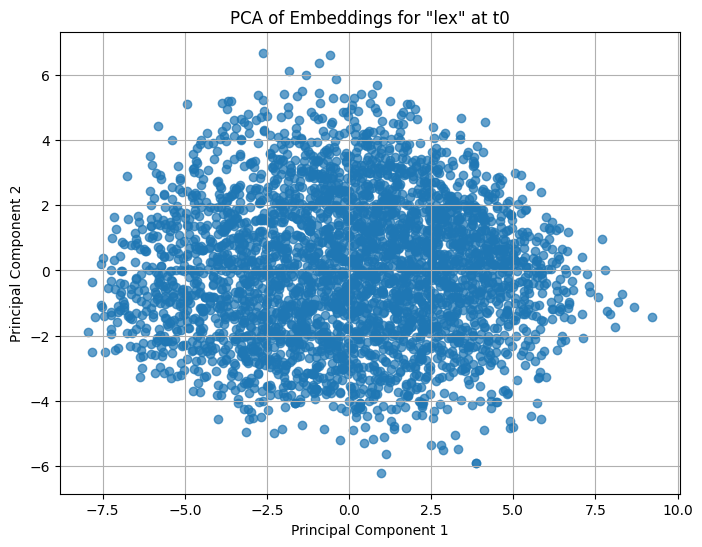

In [ ]:
# Plot the reduced embeddings for word 1, t0
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t0_word1[:, 0], reduced_embeddings_t0_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t0')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
output_path = os.path.join(dir_out, "PCA")
os.makedirs(output_path, exist_ok=True)
plot_filename_t0 = os.path.join(output_path, f"pca_embeddings_{word1}_t0.png")
plt.savefig(plot_filename_t0, dpi=300, bbox_inches='tight')

plt.show()

Plot for t1:

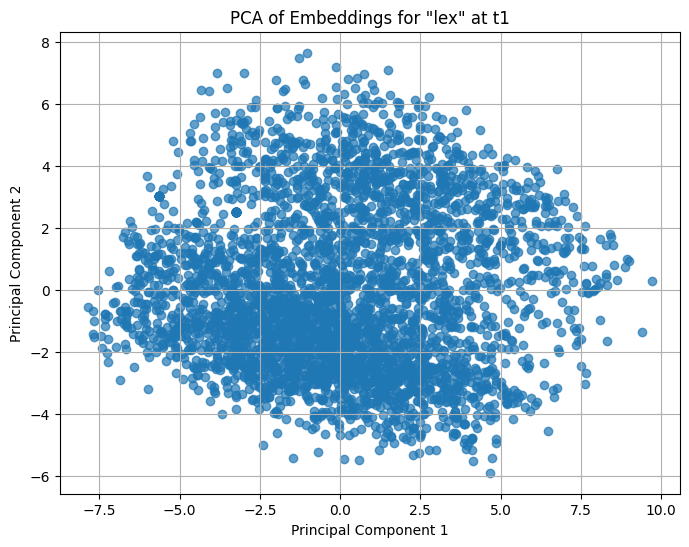

In [ ]:
# Plot the reduced embeddings for word 1, t1
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t1_word1[:, 0], reduced_embeddings_t1_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
plot_filename_t1 = os.path.join(output_path, f"pca_embeddings_{word1}_t1.png")
plt.savefig(plot_filename_t1, dpi=300, bbox_inches='tight')

plt.show()

Let's check whether the dimensionality reduction is making us lose too much in terms of representation:

In [ ]:
# Calculate explained variance for t0
explained_variance_t0 = pca_t0.explained_variance_ratio_
print(f"Explained Variance for t0: {explained_variance_t0}")
print(f"Total Explained Variance for t0: {sum(explained_variance_t0):.2f}")

# Calculate explained variance for t1
explained_variance_t1 = pca_t1.explained_variance_ratio_
print(f"Explained Variance for t1: {explained_variance_t1}")
print(f"Total Explained Variance for t1: {sum(explained_variance_t1):.2f}")

Explained Variance for t0: [0.08006308 0.03652317]
Total Explained Variance for t0: 0.12
Explained Variance for t1: [0.07518646 0.05021142]
Total Explained Variance for t1: 0.13


#### Cluster vectors for given word

Cluster:

In [ ]:
# Cluster the embeddings for the selected word (pick number of clusters based on plot)
word_embeddings_t0_word1 = {word1: embeddings_t0_word1}
word_embeddings_t1_word1 = {word1: embeddings_t1_word1}
clustered_embeddings_t0_word1 = cluster_target_embeddings(word_embeddings_t0_word1, num_clusters=2)
clustered_embeddings_t1_word1 = cluster_target_embeddings(word_embeddings_t1_word1, num_clusters=2)

# Get the clustered embeddings for the selected word
clustered_embeddings_array_t0 = clustered_embeddings_t0_word1[word1]
clustered_embeddings_array_t1 = clustered_embeddings_t1_word1[word1]

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


PCA and plot:

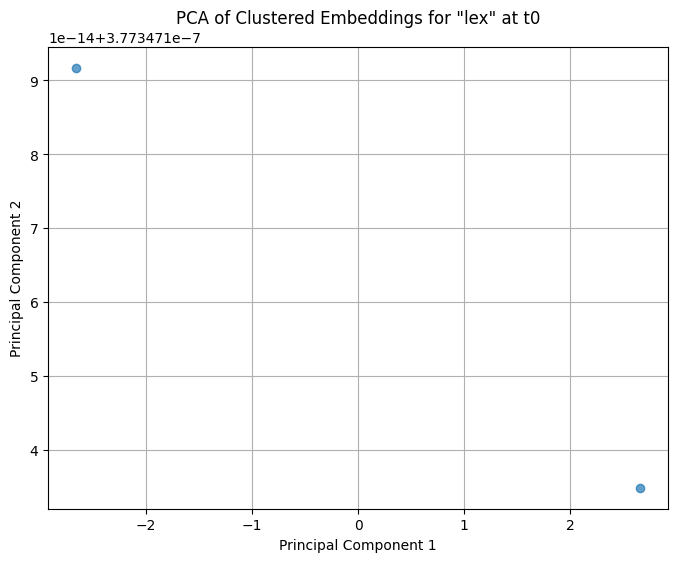

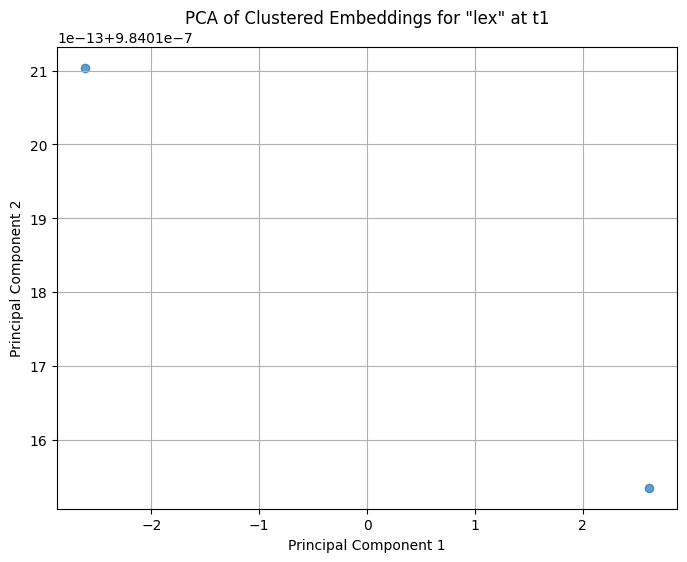

In [ ]:
reduced_clustered_embeddings_t0_word1 = pca_t0.fit_transform(clustered_embeddings_array_t0)
reduced_clustered_embeddings_t1_word1 = pca_t1.fit_transform(clustered_embeddings_array_t1)

# Plot the reduced embeddings
plt.figure(figsize=(8, 6))
plt.scatter(reduced_clustered_embeddings_t0_word1[:, 0], reduced_clustered_embeddings_t0_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Clustered Embeddings for "{word1}" at t0')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plot_filename_t0_cluster = os.path.join(output_path, f"pca_clustered_embeddings_{word1}_t0.png")
plt.savefig(plot_filename_t0_cluster, dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(reduced_clustered_embeddings_t1_word1[:, 0], reduced_clustered_embeddings_t1_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Clustered Embeddings for "{word1}" at t1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plot_filename_t1_cluster = os.path.join(output_path, f"pca_clustered_embeddings_{word1}_t1.png")
plt.savefig(plot_filename_t1_cluster, dpi=300, bbox_inches='tight')
plt.show()

#### Similarity for clustered embeddings

Next step is using some kind of similarity measure, but with clustered / sense-based embeddings I don't think we can use cosine similarity. Jesper-Shannon divergence (JSD) seems to be the thing.

## Fine-tuned LatinBERT

The fine-tuning can't really be done on a jupyter notebook: too computationally demanding. I did it on UCLA computers with A100 GPU. The relevant code is uploaded (the main file is ph_BERT.py, which however also needs latin_dataset.py and gen_berts.py).

Here, I will just load the fine-tuned model.

Remember to set `rebuild` to `True` if this is your first run, or to `False` if it is a subsequent run. If this is your first run, you can expect this section to take a few hours.

Define bert and tokenizer models paths (these may need to be changed depending on where the finetuned version of Latin BERT was installed on your machine; I created a folder on Github, but once again the models are too big for me to upload, so double-check the path after downloading):

In [50]:
# tokenizer_path = os.path.join(dir_in, "contextual_embeddings", "latin-bert-finetuned", "latin.subword.encoder")
# bert_path = os.path.join(dir_in, "contextual_embeddings", "latin-bert-finetuned")
latin_bert_finetuned = os.path.join(dir_in, "latin-bert-huggingface-finetuned")

Initialize model and tokenizer:

In [54]:
tokenizer = AutoTokenizer.from_pretrained(latin_bert_finetuned)
model = AutoModel.from_pretrained(latin_bert_finetuned)

Some weights of BertModel were not initialized from the model checkpoint at /Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings/latin-bert-huggingface-finetuned and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Try to print a few embeddings for a small section of the corpus:

In [57]:
test_sents = corpus [:10]

Tokenize and run model:

In [58]:
inputs = tokenizer(test_sents, return_tensors="pt", is_split_into_words=True, padding=True, truncation=True, add_special_tokens=True)
outputs = model(**inputs)

Calculate and print embeddings:

In [59]:
# Average over subtokens and print results
for batch_ix, (test_sent, out) in enumerate(zip(test_sents, outputs.last_hidden_state)):
    sentence_embeddings = []

    # Add [CLS] token
    cls_embedding = out[0]  # First token corresponds to [CLS]
    sentence_embeddings.append(("[CLS]", cls_embedding))

    # Process each word in the sentence
    valid_word_found = False
    for n, word in enumerate(test_sent):
        token_span = inputs.word_to_tokens(batch_ix, n)
        if token_span is not None:  # Ensure token_span is valid
            embedding = out[slice(*token_span)].mean(dim=0)  # Proper reduction
            sentence_embeddings.append((word, embedding))
            valid_word_found = True  # Mark that a valid word was found
        else:
            print(f"Warning: No token span found for word '{word}' at index {n} in batch {batch_ix}")

    # Add [SEP] token
    sep_embedding = out[-1]  # Last token corresponds to [SEP]
    sentence_embeddings.append(("[SEP]", sep_embedding))

    # Skip sentences with no valid words
    if not valid_word_found:
        # print(f"Warning: No valid words found in sentence {batch_ix}. Skipping...")
        continue

    # Print results
    for word, embedding in sentence_embeddings:
        if isinstance(embedding, torch.Tensor):  # Ensure embedding is a tensor
            embedding = embedding.tolist()  # Convert tensor to list
        print(word, ' '.join(f"{x:.5f}" for x in embedding), sep="\t")
    print()

[CLS]	-0.18780 0.41953 -0.47964 -0.42359 -0.00627 0.10425 -0.94368 0.38456 0.84722 0.03794 0.24790 -0.44067 0.43328 0.56107 0.29430 0.63536 0.46499 0.74351 0.04309 -0.02016 -0.16198 -0.36968 -0.17859 0.50762 0.15926 -0.28295 -0.44183 0.73235 0.96232 0.20244 -0.61427 -0.23589 0.48216 -0.88918 0.51359 -0.29595 -0.74599 -0.31829 0.06752 0.31616 -0.52158 1.00176 0.23970 0.58023 -0.41718 -0.18642 0.16605 -0.02921 0.05565 -0.54114 -0.21579 -0.10880 -0.20687 0.47157 -0.56662 -0.50356 0.28209 -0.04204 -0.56548 -0.44987 -1.12446 -0.00819 -0.40712 0.58519 0.05202 -0.10422 -0.18292 -0.11124 -0.06037 0.09259 0.45846 -0.81146 -0.36418 0.66402 -0.72998 -0.48405 -0.83040 0.17461 -0.90778 -0.35587 -0.53111 0.42766 0.33002 -0.47746 0.23609 0.27274 0.63070 -0.15858 -0.45990 0.43424 -0.59417 0.00896 -0.39200 -0.44536 0.45828 0.42445 -0.66877 0.10912 -0.33156 0.79449 0.25301 0.85072 -1.16529 0.61786 -0.64538 -0.42578 0.75364 0.26021 0.28558 -1.38737 -0.60525 -0.72480 0.74560 0.30607 -0.15839 -0.19863 -0.0

Extract embeddings for all subcorpora:

In [ ]:
berts_finetuned_t0 = calculate_or_load_finetuned_embeddings(time2corpus[0], latin_bert_finetuned, os.path.join(dir_out, "berts_finetuned_t0.pickle"), rebuild=False)

In [52]:
berts_finetuned_t1 = calculate_or_load_finetuned_embeddings(time2corpus[1], latin_bert_finetuned, os.path.join(dir_out, "berts_finetuned_t1.pickle"), rebuild=False)

Loading embeddings from /Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings/bert_output/berts_finetuned_t1.pickle...


In [60]:
berts_finetuned_christi = calculate_or_load_finetuned_embeddings(corpus_christi, latin_bert_finetuned, os.path.join(dir_out, "berts_finetuned_christi.pickle"), rebuild=False)

Loading embeddings from /Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings/bert_output/berts_finetuned_christi.pickle...


In [67]:
berts_finetuned_non_christi = calculate_or_load_finetuned_embeddings(corpus_non_christi, latin_bert_finetuned, os.path.join(dir_out, "berts_finetuned_non_christi.pickle"), rebuild=False)

Loading embeddings from /Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings/bert_output/berts_finetuned_non_christi.pickle...


### Average embeddings

Do that for all subcorpora:

In [61]:
rebuild = True

In [ ]:
average_embeddings_t0_finetuned, most_frequent_words_t0_finetuned = average_embeddings_per_lemma(berts_finetuned_t0, dir_out, "average_embeddings_t0_finetuned.pickle", rebuild)

In [56]:
average_embeddings_t1_finetuned, most_frequent_words_t1_finetuned = average_embeddings_per_lemma(berts_finetuned_t1, dir_out, "average_embeddings_t1_finetuned.pickle", rebuild)

Average embeddings saved to /Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings/bert_output/average_embeddings_t1_finetuned.pickle
Word: [CLS]
Embedding: [-1.92790613e-01  5.88341534e-01 -3.81173939e-01 -2.68968195e-01
 -5.26740327e-02 -8.62798020e-02 -8.29725623e-01  1.16034679e-01
  5.64483941e-01 -9.21285152e-02  1.73290655e-01 -3.60333860e-01
  4.15455312e-01  3.89593154e-01  2.09640414e-01  6.99706793e-01
  1.56303927e-01  6.91477954e-01 -4.69742306e-02 -1.46269694e-01
 -2.42044792e-01 -4.11438257e-01 -1.24028057e-01  4.25481051e-01
  1.57082081e-01 -2.15483606e-01 -3.62929732e-01  5.52824974e-01
  1.01258850e+00 -1.97476856e-02 -8.62344861e-01 -1.64055943e-01
  4.51956242e-01 -7.86850929e-01  5.67259073e-01 -3.70619416e-01
 -7.19549716e-01 -1.97723299e-01 -4.58891168e-02  5.83373129e-01
 -3.11058402e-01  7.61677384e-01  1.94843218e-01  5.40496588e-01
 -4.28127497e-01 -2.02935129e-01  2.49053329e-01 -1.34851068e-01
  1.29517093e-01 

In [62]:
average_embeddings_christi_finetuned, most_frequent_words_christi_finetuned = average_embeddings_per_lemma(berts_finetuned_christi, dir_out, "average_embeddings_christi_finetuned.pickle", rebuild)

Average embeddings saved to /Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings/bert_output/average_embeddings_christi_finetuned.pickle
Word: [CLS]
Embedding: [-1.77839264e-01  5.94736457e-01 -4.03947234e-01 -2.49380782e-01
 -1.16961457e-01  2.00035013e-02 -8.41875672e-01  2.33256251e-01
  5.00468373e-01 -6.28873482e-02  1.79273605e-01 -3.38546008e-01
  4.00963753e-01  4.20680285e-01  1.31005645e-01  7.28814423e-01
  2.16715544e-01  7.36654162e-01 -1.24402447e-02 -2.06177816e-01
 -2.21589848e-01 -4.19637501e-01 -1.60273731e-01  5.08846521e-01
  1.34338424e-01 -2.14658380e-01 -4.06204700e-01  6.06442988e-01
  1.01818550e+00  4.01527956e-02 -8.76474977e-01 -2.22605765e-01
  4.61118788e-01 -8.11053574e-01  5.42649984e-01 -3.65908384e-01
 -6.85641110e-01 -1.67728812e-01  3.15616354e-02  5.57459950e-01
 -2.37755552e-01  9.05264735e-01  9.44132134e-02  4.91391569e-01
 -4.73834366e-01 -2.71497518e-01  2.64384836e-01 -9.57713798e-02
  2.43647918

In [68]:
average_embeddings_non_christi_finetuned, most_frequent_words_non_christi_finetuned = average_embeddings_per_lemma(berts_finetuned_non_christi, dir_out, "average_embeddings_non_christi_finetuned.pickle", rebuild)

Average embeddings saved to /Users/valentinalunardi/Documents/GitHub/latinise/Christianity_semantic_change/contextual_embeddings/bert_output/average_embeddings_non_christi_finetuned.pickle
Word: [CLS]
Embedding: [-2.05177873e-01  5.83514929e-01 -3.62256706e-01 -2.85157770e-01
  6.33626594e-04 -1.74429402e-01 -8.19966495e-01  1.88708827e-02
  6.17668271e-01 -1.16391093e-01  1.68232813e-01 -3.78389001e-01
  4.27429736e-01  3.63855392e-01  2.74824798e-01  6.75408304e-01
  1.06231406e-01  6.54284298e-01 -7.56112859e-02 -9.66114551e-02
 -2.58970946e-01 -4.04591024e-01 -9.40119401e-02  3.56438130e-01
  1.75952703e-01 -2.16143757e-01 -3.27085048e-01  5.08668602e-01
  1.00759363e+00 -6.94300979e-02 -8.51038039e-01 -1.15465738e-01
  4.44482684e-01 -7.66676068e-01  5.87661624e-01 -3.74405742e-01
 -7.47679174e-01 -2.22575441e-01 -1.10117711e-01  6.04852200e-01
 -3.71881813e-01  6.42781794e-01  2.78135449e-01  5.80855191e-01
 -3.90194803e-01 -1.45841107e-01  2.36371145e-01 -1.67224288e-01
  3.4881

#### Cosine similarity for averaged embeddings

Between t0 and t1:

In [ ]:
# Compute cosine similarity for each token that appears in both t0 and t1
cosine_similarities_t0t1_finetuned = {}
for token in average_embeddings_t0_finetuned:
    if token in average_embeddings_t1_finetuned:
        embedding_t0 = average_embeddings_t0_finetuned[token].reshape(1, -1)
        embedding_t1 = average_embeddings_t1_finetuned[token].reshape(1, -1)
        similarity = cosine_similarity(embedding_t0, embedding_t1)[0][0]
        cosine_similarities_t0t1_finetuned[token] = similarity

# Print the cosine similarities for each token
for token, similarity in cosine_similarities_t0t1_finetuned.items():
    print(f"Token: {token}, Cosine Similarity: {similarity}")

In [ ]:
# Write the cosine similarities to a CSV file
cosine_sim_csv = os.path.join(dir_out, "cosine_similarities_t0t1_finetuned.csv")

with open(cosine_sim_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "Cosine Similarity"])  # Write the header
    for token, similarity in cosine_similarities_t0t1_finetuned.items():
        writer.writerow([token, similarity])

print(f"Cosine similarities saved to {cosine_sim_csv}")

Between the christian and non-christian subcorpora within t1:

In [ ]:
# Compute cosine similarity for each token that appears in both sets of embeddings
cosine_similarities_christi_nonchristi_finetuned = {}
for token in average_embeddings_christi_finetuned:
    if token in average_embeddings_non_christi_finetuned:
        embedding_christi = average_embeddings_christi_finetuned[token].reshape(1, -1)
        embedding_non_christi = average_embeddings_non_christi_finetuned[token].reshape(1, -1)
        similarity = cosine_similarity(embedding_christi, embedding_non_christi)[0][0]
        cosine_similarities_christi_nonchristi_finetuned[token] = similarity
# Print the cosine similarities for each token
for token, similarity in cosine_similarities_christi_nonchristi_finetuned.items():
    print(f"Token: {token}, Cosine Similarity: {similarity}")

In [ ]:
# Write the cosine similarities to a CSV file
cosine_sim_csv = os.path.join(dir_out, "cosine_similarities_christi_nonchristi_finetuned.csv")

with open(cosine_sim_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "Cosine Similarity"])  # Write the header
    for token, similarity in cosine_similarities_christi_nonchristi_finetuned.items():
        writer.writerow([token, similarity])

print(f"Cosine similarities saved to {cosine_sim_csv}")

Look at some "neighbours":

In [ ]:
neighbors = find_neighbors("deus", average_embeddings_t0_finetuned, top_k=10)
print(neighbors)

In [71]:
neighbors = find_neighbors("deus", average_embeddings_t1_finetuned, top_k=10)
print(neighbors)

[('Deus', 0.9985199), ('semideus', 0.7596714), ('chaldeus', 0.74812686), ('Chaldeus', 0.74370384), ('bradeus', 0.74226946), ('Semideus', 0.72658354), ('divina', 0.71500957), ('Photideus', 0.67725176), ('deo', 0.67415404), ('Asideus', 0.67149514)]


In [63]:
neighbors = find_neighbors("deus", average_embeddings_christi_finetuned, top_k=10)
print(neighbors)

[('Deus', 0.99864185), ('semideus', 0.7587694), ('chaldeus', 0.7499447), ('Chaldeus', 0.7443404), ('Semideus', 0.72671133), ('divina', 0.70967793), ('Asideus', 0.671211), ('deo', 0.6701978), ('dies', 0.6438116), ('dea', 0.6384872)]


In [69]:
neighbors = find_neighbors("deus", average_embeddings_non_christi_finetuned, top_k=10)
print(neighbors)

[('Deus', 0.99761146), ('semideus', 0.7541679), ('bradeus', 0.742687), ('divina', 0.6991949), ('chaldeus', 0.69061464), ('Photideus', 0.678707), ('deo', 0.6652934), ('dea', 0.64682376), ('denarius', 0.62054425), ('diuus', 0.6177082)]


Honesty these embeddings are much worse. I'm not sure the batch size could have made things so much worse... What else could have gone wrong?

### Cluster embeddings, whole corpus

In [ ]:
clustered_embeddings_t0_finetuned = cluster_embeddings(berts_finetuned_t0, dir_out, "clustered_embeddings_t0_finetuned.pickle", rebuild)

In [ ]:
# Playing with cosine similarity between senses to see if the clusters make sense
for word, embeddings in list(clustered_embeddings_t0_finetuned.items())[:10]:
    print(f"Word: {word}")
    if len(embeddings) > 2:
        print(f"Cosine similarity between sense 1 and sense 2: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[1].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 1 and sense 3: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 2 and sense 3: {cosine_similarity(embeddings[1].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
    print()

In [ ]:
clustered_embeddings_t1_finetuned = cluster_embeddings(berts_finetuned_t1, dir_out, "clustered_embeddings_t1_finetuned.pickle", rebuild)

In [ ]:
# Playing with cosine similarity between senses to see if the clusters make sense
for word, embeddings in list(clustered_embeddings_t1_finetuned.items())[:10]:
    print(f"Word: {word}")
    if len(embeddings) > 2:
        print(f"Cosine similarity between sense 1 and sense 2: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[1].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 1 and sense 3: {cosine_similarity(embeddings[0].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
        print(f"Cosine similarity between sense 2 and sense 3: {cosine_similarity(embeddings[1].reshape(1, -1), embeddings[2].reshape(1, -1))[0][0]}")
    print()

### Cluster embeddings, small set of words

Define small selection of words:

In [ ]:
christian_terms = ["scriptura", "lectio", "deus", "dominus", "creator", "factor", "deductor", "oratio", "lex", "altarium", "tabernaculum", "memoria", "recessus", "frater", "soror", "canticum", "virtus", "gratia", "gloria", "panis", "anima","sanctus", "beatus"]

Extract embeddings from fine-tuned corpus for the small selection of words:

In [ ]:
selected_word_embeddings_t0_finetuned = extract_selected_embeddings(berts_finetuned_t0, christian_terms)
selected_word_embeddings_t1_finetuned = extract_selected_embeddings(berts_finetuned_t1, christian_terms)

#### Plot embeddings for given word (to gather how many clusters there are)

Pick a word:

In [ ]:
word1 = 'deus'
embeddings_t0_word1 = selected_word_embeddings_t0_finetuned[word1]
embeddings_t1_word1 = selected_word_embeddings_t1_finetuned[word1]

Reduce dimensionality with PCA (adjust `n_components` as needed):

In [ ]:
# Convert the list of embeddings to a numpy array
embeddings_array_t0_word1 = np.array(embeddings_t0_word1)
embeddings_array_t1_word1 = np.array(embeddings_t1_word1)

# Perform PCA to reduce the dimensionality to 2 components
pca_t0 = PCA(n_components=2)
reduced_embeddings_t0_word1 = pca_t0.fit_transform(embeddings_array_t0_word1)
pca_t1 = PCA(n_components=2)
reduced_embeddings_t1_word1 = pca_t1.fit_transform(embeddings_array_t1_word1)

Plot for t0:

In [ ]:
# Plot the reduced embeddings for word 1, t0
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t0_word1[:, 0], reduced_embeddings_t0_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t0')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
output_path = os.path.join(dir_out, "PCA")
os.makedirs(output_path, exist_ok=True)
plot_filename_t0 = os.path.join(output_path, f"pca_embeddings_{word1}_t0_finetuned.png")
plt.savefig(plot_filename_t0, dpi=300, bbox_inches='tight')
plt.show()

Plot for t1:

In [ ]:
# Plot the reduced embeddings for word 1, t1
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t1_word1[:, 0], reduced_embeddings_t1_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
plot_filename_t1 = os.path.join(output_path, f"pca_embeddings_{word1}_t1_finetuned.png")
plt.savefig(plot_filename_t1, dpi=300, bbox_inches='tight')

plt.show()

Let's check whether the dimensionality reduction is making us lose too much in terms of representation:

In [ ]:
# Calculate explained variance for t0
explained_variance_t0 = pca_t0.explained_variance_ratio_
print(f"Explained Variance for t0: {explained_variance_t0}")
print(f"Total Explained Variance for t0: {sum(explained_variance_t0):.2f}")

# Calculate explained variance for t1
explained_variance_t1 = pca_t1.explained_variance_ratio_
print(f"Explained Variance for t1: {explained_variance_t1}")
print(f"Total Explained Variance for t1: {sum(explained_variance_t1):.2f}")